# Full loop contorl. 

## One-controller situ. 

In [1]:
# import everything
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F
from torch.optim import lr_scheduler as LR
from torch.utils.data import Dataset, DataLoader
import plotly.express as px
from functools import partial
from SimulateDatasets.ContrastiveGenerator import ContrastiveGenerator, AR1_ordered_data_gen, OrderedDataset, SampledDataset
from Network_models.CANTrainer import CANTrainer
from Network_models.PartitionedRNN import PartitionedNet
from utils.path_settings import *
import seaborn as sns
import os
from Rotations import integrate_velocities, exp_quat, q_mult, integrate_quat_sequential
from Plots.AttractorPlots import *
from Plots.globe_plots import *
import utils
import Operator.Operator as o
import copy
from Network_models.CTrainer_Pred_CAN import CTrainer_Pred_CAN
from SimulateDatasets.ContrastiveGenerator import ControlGenerator

2025-03-04 23:34:40.308181: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-04 23:34:40.389667: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-04 23:34:40.436471: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-03-04 23:34:40.436736: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-04 23:34:40.497768: I tensorflow/core/platform/cpu_feature_gua

/home/timmy/nonnormal/dummy/mental-rotations
loading


In [3]:
# set up rep net
# adjustable knobs 
knobs = {
        "batch_size" : 4096,
        "mini_batch_size" : 256,
        "repUnits" : 128,
        "model" : "PartitionedRNN", # or "PartitionedCTRNN"
        # "model": "FlexibleRNN",
        "manifold" : "t", #"custom", # or "S"
        # "manifold" : "custom",
        "dim" : 2,
        "zeroNullRep" : False,
        "zeroNullInput" : False,
        "biasRep" : True,
        "biasInput" : True,
        "hihr_identity": False, 
        "cParam" : True,
        "nonlinearity" : "tanh",
        # "nonlinearity": "BiologicalReLU",
        # "nonlinearity": "BiologicalTanh",
        # "nonlinearity": "relu",
        # "nonlinearity": "NormedReLU", 
        "inputEnveloping" : False,
        "loss" : "infonce",
        "triplet_weight" : 0, # only turn if loss is triplet
        "normalize" : False,
        "similarity_kernel" : None,
        "weight_decay_thresh" : -10,
        "L2norm_scalar": 0,
        "manifold_name": "ModifiedRingManifold",
        # "similarity_kernel": "cosine", 
        "similarity_kernel": "euclidean",
        "capacity": False, 
        "manifold_params": {
            "R":1, 
            "A":0.2, 
            "n":5,
        },
        "temperature": 0.7, 
        "invariance_weight": 1,  
        # "bidirectional": False, 
        "epsilon_max":0.1,
    }
for key, value in knobs.items():
    exec(f"{key} = {f"{value}" if type(value) != str else f'"{value}"'}")
if knobs['hihr_identity'] == False:
    knobs['hihr_identity'] = None
if knobs["L2norm_scalar"] == 0:
    knobs["L2norm_scalar"] = None
if knobs["similarity_kernel"] == "cosine":
    knobs["similarity_kernel"] = None
exclude = ["batch_size", "mini_batch_size", "triplet_weight", "loss", "weight_decay_thresh"]
if knobs["manifold"].lower() in ["s", "t"]: 
    manifold_specs = {
        "manifold_path": "SimulateDatasets.Manifolds", 
        "manifold_name": "Sphere" if knobs["manifold"].lower() == "s" else "Torus",
        "manifold_params": {"dim": knobs["dim"], 
                            }
    }
    exclude.extend(["manifold_name", "manifold_params"])


if knobs["manifold"].lower() == "custom": 
    manifold_specs = {
        "manifold_path": "SimulateDatasets.Manifolds",
        "manifold_name": knobs["manifold_name"],
        "manifold_params": knobs["manifold_params"]
    }
configs, data_specs = utils.knobs2specs_CAN(knobs)

data_gen = ContrastiveGenerator(data_specs)

# or alternatively, define trainer and load a model
trainer = CANTrainer(configs)
path = utils.load_from_lookup(configs)
try: 
    trainer.load_model(path)
    print("Model loaded via train")
except Exception as e:
    print(e)    
    print("No model to load")
    trainer.load_model(configs["save_path"][:-9] + "best_model.pth")

rnn = trainer.model.to("cuda")
rnn.eval()
rnn.rnn.eval()
torch.save(rnn, path.replace("model.pth", "model_full.pth"))

input_connected: True
1
no scheduler
Model loaded via train


In [22]:
# experiment with the operator!

joint = o.Joint({"device": "cuda", "delay": 0, "plant_state_size": 200})

In [23]:
action1 = torch.linspace(1, 2, 10).unsqueeze(0).repeat(100, 1).unsqueeze(2)
action2 = torch.linspace(2, 1, 10).unsqueeze(0).repeat(100, 1).unsqueeze(2)
action3 = torch.linspace(1, 1, 10).unsqueeze(0).repeat(100, 1).unsqueeze(2)
pseudoinverse = torch.pinverse(list(joint.readout_matrix.parameters())[0].detach().cpu()).to("cuda")

action = (pseudoinverse.cuda() @ (torch.cat([action1, action2, action3], dim=-1).cuda().reshape(-1, 3).permute(1, 0))).permute(1, 0).reshape(100, 10, 200)

fb, out = joint(action)

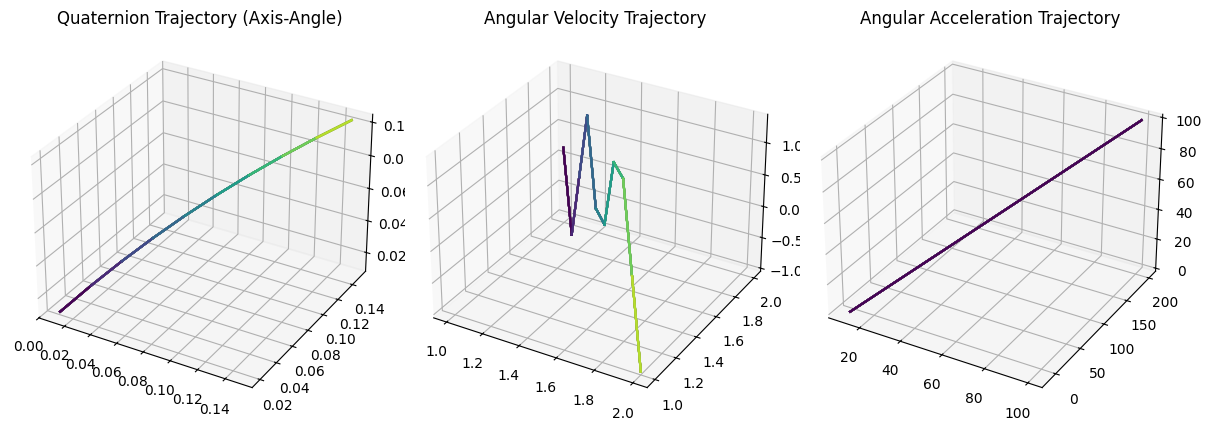

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm

# Simulated example data (batch_size=5, seq_len=100, state_space_dim=8)
batch_size = 10
seq_len = fb.shape[1]

# Simulated quaternion (4), angular velocity (3), angular acceleration (3)
state_data = fb.cpu().detach().numpy()[0:10]

# Normalize quaternions and ensure real part is positive
quaternions = state_data[:, :, :4]
angular_velocity = state_data[:, :, 4:7]
angular_acceleration = state_data[:, :, 7:]

# Normalize quaternion and ensure positive real part
for i in range(batch_size):
    norms = np.linalg.norm(quaternions[i], axis=1, keepdims=True)
    quaternions[i] /= norms
    flip_mask = quaternions[i, :, 0] < 0
    quaternions[i, flip_mask] *= -1

# Convert to axis-angle representation
real_part = quaternions[:, :, 0]
imag_part = quaternions[:, :, 1:]

angles = 2 * np.arccos(np.clip(real_part, -1, 1))  # Rotation magnitude
axes = np.where(angles[:, :, None] > 1e-6, imag_part / np.linalg.norm(imag_part, axis=2, keepdims=True), 0)
axis_positions = axes * angles[:, :, None]  # Scale unit axis by rotation magnitude

# Create figure and subplots
fig = plt.figure(figsize=(12, 6))

# 3D Quaternion Plot (Left)
ax1 = fig.add_subplot(131, projection='3d')
ax1.set_title("Quaternion Trajectory (Axis-Angle)")

# 3D Angular Velocity Plot (Right Upper)
ax2 = fig.add_subplot(132, projection='3d')
ax2.set_title("Angular Velocity Trajectory")

# 3D Angular Acceleration Plot (Right Lower)
ax3 = fig.add_subplot(133, projection='3d')
ax3.set_title("Angular Acceleration Trajectory")

# Generate colormap
colors = cm.viridis(np.linspace(0, 1, seq_len))

for i in range(batch_size):
    # Quaternion trajectory
    ax1.plot(axis_positions[i, :, 0], axis_positions[i, :, 1], axis_positions[i, :, 2], color='gray', alpha=0.5)
    for j in range(seq_len - 1):
        ax1.plot(axis_positions[i, j:j+2, 0], axis_positions[i, j:j+2, 1], axis_positions[i, j:j+2, 2], color=colors[j])

    # Angular velocity trajectory
    ax2.plot(angular_velocity[i, :, 0], angular_velocity[i, :, 1], angular_velocity[i, :, 2], color='gray', alpha=0.5)
    for j in range(seq_len - 1):
        ax2.plot(angular_velocity[i, j:j+2, 0], angular_velocity[i, j:j+2, 1], angular_velocity[i, j:j+2, 2], color=colors[j])

    # Angular acceleration trajectory
    ax3.plot(angular_acceleration[i, :, 0], angular_acceleration[i, :, 1], angular_acceleration[i, :, 2], color='gray', alpha=0.5)
    for j in range(seq_len - 1):
        ax3.plot(angular_acceleration[i, j:j+2, 0], angular_acceleration[i, j:j+2, 1], angular_acceleration[i, j:j+2, 2], color=colors[j])

# Show plot
plt.tight_layout()
plt.show()

In [13]:
# Set up the dynamical network to be controlled
# what we must do is to set up the forward function of the plant (which has its own dynamical system) to be the following:
# forawrd(u, h, dt) -> h_new, y (h_new can be the same as y)

# use a simplified plant for now:
class DecayPlant(nn.Module): 
    def __init__(self, dim, dim_input=None, dt=0.01, constant = 0.9): 
        super(DecayPlant, self).__init__()
        self.dt = dt
        self.A = nn.Linear(dim, dim, False)
        self.dim_input = dim_input if dim_input is not None else dim
        self.B = nn.Linear(dim_input, dim, False)
        with torch.no_grad():
            # self.A.weight.copy_(torch.diag(-torch.rand(dim,)).cuda())
            self.A.weight.copy_(-constant * torch.eye(dim).cuda())
            # self.B.weight.copy_(torch.rand(dim, self.dim_input).cuda())
        for param in self.parameters(): 
            param.requires_grad = False
        self.dim = dim
        self.state_dim = dim

        self.h = torch.zeros(1, dim).cuda()
    def forward(self, u, h=None, dt=None): 
        update_self_h = False
        if h is None: 
            h = self.h
            update_self_h = True
        if dt is None:
            dt = self.dt
        h_new = h + self.A(h) * dt + self.B(u) * dt # Euler discretization - fine for now!
        if update_self_h: 
            self.h = h_new.detach()
        return h_new, h_new
# let's visualize a few trajectories
def visualize_system_behavior(plant, num_steps=100):
    dt = plant.dt
    dim = plant.B.weight.shape[0]  # Output dimension
    time = np.arange(num_steps) * dt

    # Define different input signals
    impulse = torch.zeros(num_steps, plant.dim_input).cuda()
    impulse[0] = 1.0  # Delta function

    step = torch.ones(num_steps, plant.dim_input).cuda()  # Step function

    step_up_down = torch.zeros(num_steps, plant.dim_input).cuda()
    step_up_down[:num_steps // 2] = 1.0  # Step up
    step_up_down[num_steps // 2:] = 0.5  # Step down

    ramp_up = torch.linspace(0, 1, num_steps).cuda().unsqueeze(1).expand(-1, plant.dim_input)  # Linearly increasing input

    # Store responses
    responses = {}
    for name, u in zip(["Impulse", "Step", "Step Up-Down", "Ramp-Up"], [impulse, step, step_up_down, ramp_up]):
        h = torch.zeros(1, dim).cuda()  # Reset hidden state
        response = []
        for i in range(num_steps):
            h, _ = plant(u[i].unsqueeze(0), h)
            response.append(h.cpu().numpy().squeeze())
        responses[name] = np.array(response)

    # Plot the responses
    fig, axs = plt.subplots(2, 2, figsize=(10, 8))

    for ax, (name, response) in zip(axs.flat, responses.items()):
        ax.plot(time, response)
        ax.set_title(f"{name} Response")
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("State")

    plt.tight_layout()
    plt.show()

# Create plant and visualize responses

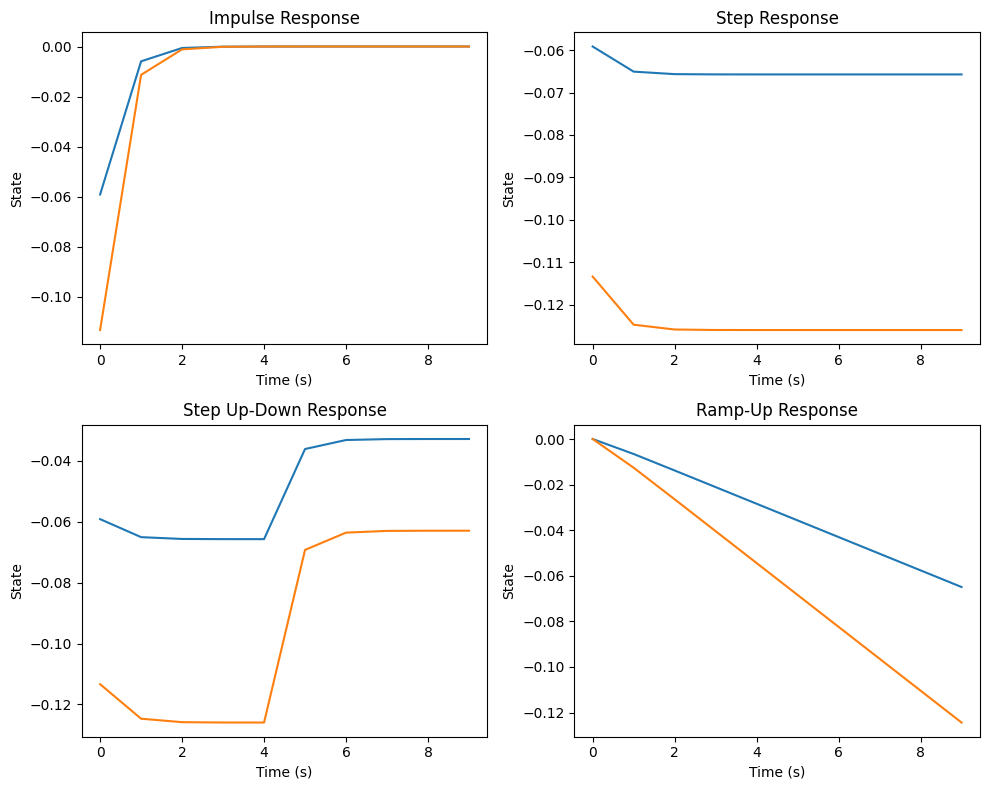

In [14]:
plant = DecayPlant(dim=2, dim_input=2, dt=1).cuda()
visualize_system_behavior(plant, num_steps=10)

In [15]:
from Network_models.PIDController import PredControlNetCAN, PredControlNetCAN_2

In [28]:
class SingleLayerLM(nn.Module): 
    def __init__(self, input_size, output_size, hidden_size=0, activation="tanh"): 
        super(SingleLayerLM, self).__init__()
        
        self.hidden_size = hidden_size
        self.input_size = input_size
        self.output_size = output_size
        self.activation = getattr(torch, activation)

        if hidden_size > 0:
            self.W_ih = nn.Linear(input_size, hidden_size, True)  # Input-to-hidden
            self.W_hh = nn.Linear(hidden_size, hidden_size, True)  # Hidden-to-hidden
            self.W_ho = nn.Linear(hidden_size, output_size, True)  # Hidden-to-output
            self.h0 = nn.Parameter(torch.zeros(1, hidden_size))  # Initial hidden state
        else:
            self.W_ih = None
            self.W_hh = None
            self.W_ho = None
            self.h0 = None
        self.W_io = nn.Linear(input_size, output_size, True)  # Input-to-output direct mapping

    def forward(self, x, h=None):
        if self.hidden_size > 0:
            if h is None:
                h = self.h0.expand(x.shape[0], -1) 
            h = self.activation(self.W_ih(x) + self.W_hh(h))  
            y = self.W_io(x) + self.W_ho(h)  # Output depends on both input and hidden state
        else:
            y = self.W_io(x)  # Simple feedforward case
        y = self.activation(y)
        
        return h, y

class DecayPlant(nn.Module): 
    def __init__(self, dim, dim_input=None, dt=0.01): 
        super(DecayPlant, self).__init__()
        self.dt = dt
        self.A = nn.Linear(dim, dim, False)
        self.dim_input = dim_input if dim_input is not None else dim
        self.B = nn.Linear(dim_input, dim, False)
        with torch.no_grad():
            # self.A.weight.copy_(torch.diag(-torch.rand(dim,)).cuda())
            self.A.weight.copy_(-torch.eye(dim).cuda())
            self.B.weight.copy_(torch.rand(dim, self.dim_input).cuda())
        for param in self.parameters(): 
            param.requires_grad = False
        self.dim = dim
        self.state_dim = dim

        self.h = torch.zeros(1, dim).cuda()
    def forward(self, u, h=None, dt=None): 
        update_self_h = False
        if h is None: 
            h = self.h
            update_self_h = True
        if dt is None:
            dt = self.dt
        h_new = h + self.A(h) * dt + self.B(u) * dt # Euler discretization - fine for now!
        if update_self_h: 
            self.h = h_new.detach()
        return h_new, h_new


In [11]:
returned = list(controller.forward(torch.randn(10, 512).float(), torch.randn(10, 512).float(), 10, return_control_trajectory=True))

In [114]:
names = [
    "hi_trajectory",
    "control_trajectory",
    "error_trajectory",
    "ht_trajectory",
    "ht_im1_trajectory",
    "ht_im2_trajectory",
    "action_trajectory",
    "action_recovery_error_trajectory",
    "action_correction_trajectory",
    "out_trajectory",
]
for n, r in zip(names, returned): 
    print(n + " shape: " + str(r.shape))
    if r.shape[-1]>0:
        print(r[0, :])

hi_trajectory shape: torch.Size([10, 10, 512])
tensor([[ 0.4967, -0.9066, -0.0507,  ...,  0.6159, -0.3961,  0.5336],
        [-0.8991, -0.6873,  0.5945,  ...,  0.9026, -0.9578, -0.2676],
        [-0.9233,  0.3806, -0.7466,  ...,  0.3541, -0.9866, -0.8494],
        ...,
        [ 0.2283, -0.6786, -0.9139,  ..., -0.8099, -0.4066,  0.8806],
        [ 0.1755, -0.6945, -0.3603,  ..., -0.9006, -0.5056,  0.9796],
        [-0.0337, -0.5201,  0.8289,  ..., -0.8795, -0.7711,  0.9772]],
       device='cuda:0', grad_fn=<SliceBackward0>)
control_trajectory shape: torch.Size([10, 10, 32])
tensor([[ 2.7851e-02,  3.5556e-03, -2.4115e-01, -3.6108e-01, -3.8090e-01,
          4.3021e-01, -4.7871e-02,  6.3506e-01,  2.7985e-01,  2.3424e-01,
          9.3604e-01,  3.2592e-01, -6.9747e-01, -1.2873e-01, -9.0769e-04,
          1.1099e-01, -4.2138e-01,  1.2604e-01,  6.9692e-02,  7.4745e-03,
          2.9086e-02, -3.8847e-01, -7.0772e-01,  1.7540e-01, -1.0402e-01,
          1.1251e-01,  7.9434e-01,  4.4189e-01, 

We are getting closer to training the thing. Before that, redo the analysis on the representation. 

In [10]:
class CosineActivation(nn.Module):
    def __init__(self, theta):
        super(CosineActivation, self).__init__()
        """theta is the angle of the cosine activation, 
        if it is a list, then output an expansive feature map
        """
        self.theta = theta

    def forward(self, x):
        if isinstance(self.theta, list):
            return torch.cat([torch.cos(x * theta) for theta in self.theta], dim=1)
        return torch.cos(x * self.theta)
class CosineSineActivation(nn.Module):
    def __init__(self, theta):
        super(CosineSineActivation, self).__init__()
        """theta is the angle of the cosine activation, 
        if it is a list, then output an expansive feature map
        """
        self.theta = theta

    def forward(self, x):
        if isinstance(self.theta, list):
            return torch.cat([torch.cos(x * theta) for theta in self.theta] + [torch.sin(x * theta) for theta in self.theta], dim=1)
        return torch.cat([torch.cos(x * self.theta), torch.sin(x * self.theta)], dim=1)
    
def expand_trig(theta):
    """
    theta: torch.tensor(batch_size, dim): thetas of different dimensions
    """
    return torch.cat([torch.cos(theta), torch.sin(theta)], dim=1)

def pos2theta(y): 
    dim = y.shape[-1]//2
    theta = torch.zeros((*y.shape[:-1], dim))
    for i in range(dim):
        theta[..., i] = torch.atan2(y[..., i + dim], y[..., i])
    return theta

d = data_gen.generate_data(10, disregard_n_samples=False)
dpositions = d.positions.cpu().numpy()

rep_only = False
mapnet = nn.Sequential(
    # CosineActivation(theta=np.pi/2),
    # ArcCosineActivation(theta=np.pi/2),
    CosineSineActivation(theta=[0.5, 1, 2]),
    nn.Linear(dpositions.shape[1] * 6, 128), 
    nn.ReLU(),
    # CosineSineActivation(theta=[0.5, 1, 2]),
    # nn.Linear(128, 128),
    # nn.ReLU(),
    nn.Linear(128, 128),
    nn.ReLU(),
    nn.Linear(128, rnn.rnn.rep_units if rep_only else rnn.rnn.hidden_size),
    # nn.Linear(dpositions.shape[1], rnn.rnn.rep_units if rep_only else rnn.rnn.hidden_size),
    rnn.rnn.nonlinearity_fn if rnn.rnn.nonlinearity_fn is not torch.nn.functional.tanh else nn.Tanh(), 
)
readoutnet = nn.Sequential(
    nn.Linear(rnn.rnn.rep_units, 128),
    nn.ReLU(),
    nn.Linear(128, 128),
    nn.ReLU(),
    nn.Linear(128, dpositions.shape[1]) if dim == 3 else nn.Linear(128, dpositions.shape[1]*2),
)

0.1


In [12]:
# TRAIN A MAPNET
p_resample = 0.02
epochs = 100
mini_batch_size = 30
optimizer = optim.Adam(mapnet.parameters(), lr=0.003)

total_trials = 100 if dim != 1 else 10000
total_trials = 25 if dim == 3 else total_trials

d = data_gen.generate_data(total_trials, disregard_n_samples=False) 
X_val = d.positions
with torch.no_grad():
    Y_val = rnn(d.data_base, truncate_output=rep_only)[:, -1, :]

d = data_gen.generate_data(total_trials, disregard_n_samples=False) 
X_train = d.positions + (torch.randn_like(d.positions) < 0) * 2 * np.pi - (torch.randn_like(d.positions) < 0) * 2 * np.pi
with torch.no_grad():
    Y_train = rnn(d.data_base, truncate_output=rep_only)[:, -1, :]

train_set = torch.utils.data.TensorDataset(X_train, Y_train)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=mini_batch_size, shuffle=True, generator=torch.Generator("cpu"))
val_set = torch.utils.data.TensorDataset(X_val, Y_val)
val_loader = torch.utils.data.DataLoader(val_set, batch_size=mini_batch_size, shuffle=True, generator=torch.Generator("cpu"))

train_losses = []
val_losses = []

mapnet = mapnet.train().float()
mapnet.to("cuda")
for epoch in range(epochs):
    for X, Y in train_loader:
        X, Y = X.to("cuda").float(), Y.to("cuda").float()
        optimizer.zero_grad()
        Y_hat = mapnet(X)
        loss = F.mse_loss(Y_hat, Y)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
    for X, Y in val_loader:
        X, Y = X.to("cuda").float(), Y.to("cuda").float()
        
        Y_hat = mapnet(X)
        loss = F.mse_loss(Y_hat, Y)
        val_losses.append(loss.item())
    if torch.rand(1) < p_resample:
        d = data_gen.generate_data(total_trials, disregard_n_samples=False) 
        X_train = d.positions + (torch.randn_like(d.positions) < 0) * 2 * np.pi - (torch.randn_like(d.positions) < 0) * 2 * np.pi if dim == 1 else d.positions
        with torch.no_grad():
            Y_train = rnn(d.data_base, truncate_output=rep_only)[:, -1, :]
        train_set = torch.utils.data.TensorDataset(X_train, Y_train)
        train_loader = torch.utils.data.DataLoader(train_set, batch_size=mini_batch_size, shuffle=True, generator=torch.Generator("cpu"))
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Train Loss: {train_losses[-1]}, Val Loss: {val_losses[-1]}")

0.1
0.1
Epoch 0, Train Loss: 0.01592913269996643, Val Loss: 0.01338158082216978
Epoch 10, Train Loss: 0.031266599893569946, Val Loss: 0.0439266636967659
Epoch 20, Train Loss: 0.013322630897164345, Val Loss: 0.020085880532860756
Epoch 30, Train Loss: 0.010300518944859505, Val Loss: 0.01565481163561344
0.1
Epoch 40, Train Loss: 0.022747963666915894, Val Loss: 0.00638049328699708
Epoch 50, Train Loss: 0.012989923357963562, Val Loss: 0.017301414161920547
Epoch 60, Train Loss: 0.011081889271736145, Val Loss: 0.024274008348584175


KeyboardInterrupt: 

In [13]:
rnn.rnn.rep_units

128

In [14]:
#TRAIN A READOUTNET
p_resample = 0.02
epochs = 100
mini_batch_size = 300
optimizer = optim.Adam(readoutnet.parameters(), lr=0.003)

total_trials = 100 if dim != 1 else 10000
total_trials = 25 if dim == 3 else total_trials

d = data_gen.generate_data(total_trials, disregard_n_samples=False) 
Y_val = d.positions
Y_val = expand_trig(d.positions) if dim != 3 else d.positions
with torch.no_grad():
    X_val = rnn(d.data_base, truncate_output=False)[:, -1, -rnn.rnn.rep_units:]

d = data_gen.generate_data(total_trials, disregard_n_samples=False) 
Y_train = d.positions
Y_train = expand_trig(d.positions) if dim != 3 else d.positions
with torch.no_grad():
    X_train = rnn(d.data_base, truncate_output=False)[:, -1, -rnn.rnn.rep_units:]

train_set = torch.utils.data.TensorDataset(X_train, Y_train)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=mini_batch_size, shuffle=True, generator=torch.Generator("cpu"))
val_set = torch.utils.data.TensorDataset(X_val, Y_val)
val_loader = torch.utils.data.DataLoader(val_set, batch_size=mini_batch_size, shuffle=True, generator=torch.Generator("cpu"))

train_losses = []
val_losses = []

readoutnet = readoutnet.train().float()
readoutnet.to("cuda")
for epoch in range(epochs):
    for X, Y in train_loader:
        X, Y = X.to("cuda").float(), Y.to("cuda").float()
        optimizer.zero_grad()
        Y_hat = readoutnet(X)
        if dim == 3:
            Y_hat = Y_hat/ torch.norm(Y_hat, dim=-1, keepdim=True)
        # loss = Rot.geodesic_distance(Y_hat, Y).mean()
        loss = F.mse_loss(Y_hat, Y)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
    for X, Y in val_loader:
        X, Y = X.to("cuda").float(), Y.to("cuda").float()
        
        Y_hat = readoutnet(X)
        if dim == 3: 
            Y_hat = Y_hat/torch.norm(Y_hat, dim=-1, keepdim=True)
        # loss = Rot.geodesic_distance(Y_hat, Y).mean()
        loss = F.mse_loss(Y_hat, Y)
        val_losses.append(loss.item())
    if torch.rand(1) < p_resample:
        d = data_gen.generate_data(total_trials, disregard_n_samples=False)
        Y_train = expand_trig(d.positions) if dim != 3 else d.positions
        with torch.no_grad():
            X_train = rnn(d.data_base, truncate_output=False)[:, -1, -rnn.rnn.rep_units:]
        train_set = torch.utils.data.TensorDataset(X_train, Y_train)
        train_loader = torch.utils.data.DataLoader(train_set, batch_size=mini_batch_size, shuffle=True, generator=torch.Generator("cpu"))
    if epoch % 10 == 0:
      print(f"Epoch {epoch}, Train Loss: {train_losses[-1]}, Val Loss: {val_losses[-1]}")

0.1
0.1
Epoch 0, Train Loss: 0.007092391140758991, Val Loss: 0.008111984468996525
Epoch 10, Train Loss: 0.0019882412161678076, Val Loss: 0.002392672235146165
Epoch 20, Train Loss: 0.0022781365551054478, Val Loss: 0.0022654212079942226
Epoch 30, Train Loss: 0.001912957988679409, Val Loss: 0.003542857011780143
0.1
Epoch 40, Train Loss: 0.002036112127825618, Val Loss: 0.002270441735163331
0.1
Epoch 50, Train Loss: 0.0019078972982242703, Val Loss: 0.0019966764375567436
Epoch 60, Train Loss: 0.0016952275764197111, Val Loss: 0.0017709287349134684
Epoch 70, Train Loss: 0.0012403845321387053, Val Loss: 0.0017693910049274564
Epoch 80, Train Loss: 0.0019153159810230136, Val Loss: 0.0017267345683649182
Epoch 90, Train Loss: 0.0013909765984863043, Val Loss: 0.0016717431135475636


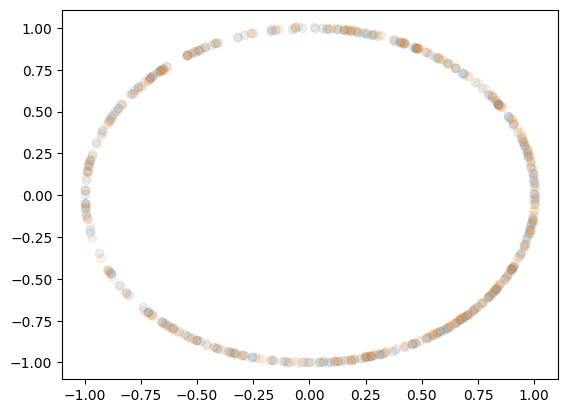

In [206]:
plt.plot(Y.cpu().numpy()[:, 0], Y.cpu().numpy()[:, 1], "o", alpha=0.1)
plt.plot(Y_hat.cpu().detach().numpy()[:, 0], Y_hat.cpu().detach().numpy()[:, 1], "o", alpha=0.1)

In [18]:
torch.save(readoutnet, path.replace("model.pth", "readoutnet.pth"))
torch.save(mapnet, path.replace("model.pth", "mapnet.pth"))

In [6]:
mapnet = torch.load(path.replace("model.pth", "mapnet.pth"))
readoutnet = torch.load(path.replace("model.pth", "readoutnet.pth"))

In [15]:
# let's get a uniform grid of points

d = data_gen.generate_data(total_trials, disregard_n_samples=False)
pos = d.positions
d.theta = pos[:, 0]
# d.theta = torch.atan2(pos[:, 1], pos[:, 0])
if d.positions.shape[-1] <4:
    d.quats = torch.cat([d.positions, torch.zeros(d.positions.shape[:-1]+(4 - d.positions.shape[-1],), device=d.positions.device)], dim=-1)
else: 
    d.quats = d.positions
d.quats *= d.quats[:, 0:1].sign()
X_train = d.positions + (torch.randn_like(d.positions) < 0) * 2 * np.pi - (torch.randn_like(d.positions) < 0) * 2 * np.pi
rep_only = False
with torch.no_grad():
    Y_train = rnn(d.data_base, truncate_output=rep_only)[:, -1, :]


xy = X_train
reps = Y_train
# reps += rnn.rnn.c.reshape(1, -1)
reps = reps - reps.mean(dim=0).detach()
# reps = F.normalize(reps, p=2, dim=1)

u, s, v = torch.svd(reps)

fig = plt.figure()
# Project to top 3 singular vectors
PCs_all = reps @ v[:, :]
b = 0
PCs = PCs_all[:, b:b + 3].cpu()

if manifold == "s":
    c = (torch.acos(torch.clamp(d.quats[:, 0],-1, 1))).cpu().numpy() * 2
    cx = d.quats[:, 1:]
    cx = (cx/cx.norm(dim = -1, keepdim=True)).cpu().numpy()
    fig1 = px.scatter_3d(x = PCs[:, 0].detach().numpy(), y = PCs[:, 1].detach().numpy(), z = PCs[:, 2].detach().numpy(), color = c
                        # set colorbar to viridis
                        , color_continuous_scale = "turbo", opacity=0.4,
                        # ,color_continuous_scale = "RdBu_r", opacity=0.4,  
                    )
    ptsize = 2
    fig1.update_traces(marker=dict(size=ptsize))

    fig1.update_layout(coloraxis_colorbar=dict(title="theta"))

    fig1.show()
    labs = ["axis_x", "axis_y", "axis_z"]
    for i in range(3): 
        fign = px.scatter_3d(x = PCs[:, 0].detach().numpy(), y = PCs[:, 1].detach().numpy(), z = PCs[:, 2].detach().numpy(), color = cx[:, i]
                        # set colorbar to viridis
                        ,color_continuous_scale = "RdBu_r", opacity=0.4,  
                    )
        ptsize = 2
        fign.update_traces(marker=dict(size=ptsize))

        
        fign.update_layout(coloraxis_colorbar=dict(title=labs[i]))
        fign.show()
elif manifold == "custom":
    c = data.theta.cpu().numpy()
    fig1 = px.scatter_3d(x = PCs[:, 0].detach().numpy(), y = PCs[:, 1].detach().numpy(), z = PCs[:, 2].detach().numpy(), color = c
                        # set colorbar to viridis
                        , color_continuous_scale = "turbo", opacity=0.4,
                        # ,color_continuous_scale = "RdBu_r", opacity=0.4,  
                    )
    ptsize = 2
    fig1.update_traces(marker=dict(size=ptsize))

    red_dot_position = -((rnn_test.rnn.c + offset) @ v[:, b:b + 3]).cpu().detach()
    fig1.add_scatter3d(
        x=[red_dot_position[0]], 
        y=[red_dot_position[1]], 
        z=[red_dot_position[2]], 
        mode="markers", 
        marker=dict(size=10, color="red"), 
        name="Red Dot",
        showlegend=False
    )
    fig1.update_layout(coloraxis_colorbar=dict(title="theta"))

    fig1.show()

else: 
    c = xy.cpu()
    # c0 = abs(c[:, 0])
    c0 = c[:, 0]
    while max(c0)> np.pi or min(c0) < -np.pi:
        c0 = c0 + 2 * np.pi * (c0 < -np.pi) - 2 * np.pi * (c0 > np.pi)

    fig1 = px.scatter_3d(x = PCs[:, 0].detach().numpy(), y = PCs[:, 1].detach().numpy(), z = PCs[:, 2].detach().numpy(), color = c0
                        # set colorbar to viridis
                        ,color_continuous_scale = "turbo", opacity=0.4,  
                        )



    if dim == 2 or dim == 3: 
        c1 = c[:, 1]
        while max(c1)> np.pi or min(c1) < -np.pi:
            c1 = c1 + 2 * np.pi * (c1 < -np.pi) - 2 * np.pi * (c1 > np.pi)


        #jot a 3D plot by px
        fig2 = px.scatter_3d(x = PCs[:, 0].detach().numpy(), y = PCs[:, 1].detach().numpy(), z = PCs[:, 2].detach().numpy(), color = c1
                            # set colorbar to viridis
                            ,color_continuous_scale = "turbo", opacity=0.4
                            )
    if dim == 3: 
        c2 = c[:, 2]
        while max(c2)> np.pi or min(c2) < -np.pi:
            c2 = c2 + 2 * np.pi * (c2 < -np.pi) - 2 * np.pi * (c2 > np.pi)


        #jot a 3D plot by px
        fig3 = px.scatter_3d(x = PCs[:, 0].detach().numpy(), y = PCs[:, 1].detach().numpy(), z = PCs[:, 2].detach().numpy(), color = c2
                            # set colorbar to viridis
                            ,color_continuous_scale = "turbo", opacity=0.4
                            )
    ptsize = 2
    fig1.update_traces(marker=dict(size=ptsize))
    fig1.show()
    if dim == 2 or dim == 3:
        fig2.update_traces(marker=dict(size=ptsize))
        fig2.show()
    if dim == 3:
        fig3.update_traces(marker=dict(size=ptsize))
        fig3.show()


0.1


<Figure size 640x480 with 0 Axes>

In [17]:
n_points = total_trials 
# x = np.linspace(-1, 1, n_points) * np.pi
# y = np.linspace(-1, 1, n_points) * np.pi
# z = np.linspace(-1, 1, n_points) * np.pi
# x_grid, y_grid, z_grid = np.meshgrid(x, y, z)
# xy = np.stack([x_grid.flatten(), y_grid.flatten(), z_grid.flatten()], axis=1)
# xy = torch.tensor(xy).to("cuda").float()

# xy = torch.randn(n_points**3, 4)
# xy = (xy / xy.norm(dim=-1, keepdim=True)).to("cuda").float()
xy = d.quats.float() if dim == 3 else d.positions.float()
mapnet = mapnet.float().cuda()
reps = mapnet(xy.cuda()).detach()
reps = reps - reps.mean(dim=0).detach()
u, s, v = torch.svd(reps)

fig = plt.figure()
# Project to top 3 singular vectors
PCs_all = reps @ v[:, :]
b = 0
PCs = PCs_all[:, b:b + 3].cpu()


if manifold == "s":
    c = (torch.acos(torch.clamp(xy[:, 0],-1, 1))).cpu().numpy() * 2
    cx = xy[:, 1:]
    cx = (cx/cx.norm(dim = -1, keepdim=True)).cpu().numpy()
    fig1 = px.scatter_3d(x = PCs[:, 0].detach().numpy(), y = PCs[:, 1].detach().numpy(), z = PCs[:, 2].detach().numpy(), color = c
                        # set colorbar to viridis
                        , color_continuous_scale = "turbo", opacity=0.4,
                        # ,color_continuous_scale = "RdBu_r", opacity=0.4,  
                    )
    ptsize = 2
    fig1.update_traces(marker=dict(size=ptsize))

    fig1.update_layout(coloraxis_colorbar=dict(title="theta"))

    fig1.show()
    labs = ["axis_x", "axis_y", "axis_z"]
    for i in range(3): 
        fign = px.scatter_3d(x = PCs[:, 0].detach().numpy(), y = PCs[:, 1].detach().numpy(), z = PCs[:, 2].detach().numpy(), color = cx[:, i]
                        # set colorbar to viridis
                        ,color_continuous_scale = "RdBu_r", opacity=0.4,  
                    )
        ptsize = 2
        fign.update_traces(marker=dict(size=ptsize))

        
        fign.update_layout(coloraxis_colorbar=dict(title=labs[i]))
        fign.show()
elif manifold == "custom":
    c = data.theta.cpu().numpy()
    fig1 = px.scatter_3d(x = PCs[:, 0].detach().numpy(), y = PCs[:, 1].detach().numpy(), z = PCs[:, 2].detach().numpy(), color = c
                        # set colorbar to viridis
                        , color_continuous_scale = "turbo", opacity=0.4,
                        # ,color_continuous_scale = "RdBu_r", opacity=0.4,  
                    )
    ptsize = 2
    fig1.update_traces(marker=dict(size=ptsize))

    red_dot_position = -((rnn_test.rnn.c + offset) @ v[:, b:b + 3]).cpu().detach()
    fig1.add_scatter3d(
        x=[red_dot_position[0]], 
        y=[red_dot_position[1]], 
        z=[red_dot_position[2]], 
        mode="markers", 
        marker=dict(size=10, color="red"), 
        name="Red Dot",
        showlegend=False
    )
    fig1.update_layout(coloraxis_colorbar=dict(title="theta"))

    fig1.show()

else: 
    c = xy.cpu()
    # c0 = abs(c[:, 0])
    c0 = c[:, 0]
    while max(c0)> np.pi or min(c0) < -np.pi:
        c0 = c0 + 2 * np.pi * (c0 < -np.pi) - 2 * np.pi * (c0 > np.pi)

    fig1 = px.scatter_3d(x = PCs[:, 0].detach().numpy(), y = PCs[:, 1].detach().numpy(), z = PCs[:, 2].detach().numpy(), color = c0
                        # set colorbar to viridis
                        ,color_continuous_scale = "turbo", opacity=0.4,  
                        )



    if dim == 2 or dim == 3: 
        c1 = c[:, 1]
        while max(c1)> np.pi or min(c1) < -np.pi:
            c1 = c1 + 2 * np.pi * (c1 < -np.pi) - 2 * np.pi * (c1 > np.pi)


        #jot a 3D plot by px
        fig2 = px.scatter_3d(x = PCs[:, 0].detach().numpy(), y = PCs[:, 1].detach().numpy(), z = PCs[:, 2].detach().numpy(), color = c1
                            # set colorbar to viridis
                            ,color_continuous_scale = "turbo", opacity=0.4
                            )
    if dim == 3: 
        c2 = c[:, 2]
        while max(c2)> np.pi or min(c2) < -np.pi:
            c2 = c2 + 2 * np.pi * (c2 < -np.pi) - 2 * np.pi * (c2 > np.pi)


        #jot a 3D plot by px
        fig3 = px.scatter_3d(x = PCs[:, 0].detach().numpy(), y = PCs[:, 1].detach().numpy(), z = PCs[:, 2].detach().numpy(), color = c2
                            # set colorbar to viridis
                            ,color_continuous_scale = "turbo", opacity=0.4
                            )
    ptsize = 2
    fig1.update_traces(marker=dict(size=ptsize))
    fig1.show()
    if dim == 2 or dim == 3:
        fig2.update_traces(marker=dict(size=ptsize))
        fig2.show()
    if dim == 3:
        fig3.update_traces(marker=dict(size=ptsize))
        fig3.show()



<Figure size 640x480 with 0 Axes>

In [25]:
torch.save(mapnet, path.replace("model.pth", "mapnet.pth"))

# Simple setup codes:

In [10]:
# import everything
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F
from torch.optim import lr_scheduler as LR
from torch.utils.data import Dataset, DataLoader
import plotly.express as px
from functools import partial
from SimulateDatasets.ContrastiveGenerator import ContrastiveGenerator, AR1_ordered_data_gen, OrderedDataset, SampledDataset
from Network_models.CANTrainer import CANTrainer
from Network_models.PartitionedRNN import PartitionedNet
from utils.path_settings import *
import seaborn as sns
import os
from Rotations import integrate_velocities, exp_quat, q_mult, integrate_quat_sequential
from Plots.AttractorPlots import *
from Plots.globe_plots import *
import utils
import Operator.Operator as o
import copy
from Network_models.CTrainer_Pred_CAN import CTrainer_Pred_CAN
from SimulateDatasets.ContrastiveGenerator import ControlGenerator

# set up rep net
# adjustable knobs 
knobs = {
        "batch_size" : 4096,
        "mini_batch_size" : 256,
        "repUnits" : 128,
        "model" : "PartitionedRNN", # or "PartitionedCTRNN"
        # "model": "FlexibleRNN",
        "manifold" : "t", #"custom", # or "S"
        # "manifold" : "custom",
        "dim" : 1,
        "zeroNullRep" : False,
        "zeroNullInput" : False,
        "biasRep" : True,
        "biasInput" : True,
        "hihr_identity": False, 
        "cParam" : True,
        "nonlinearity" : "tanh",
        # "nonlinearity": "BiologicalReLU",
        # "nonlinearity": "BiologicalTanh",
        # "nonlinearity": "relu",
        # "nonlinearity": "NormedReLU", 
        "inputEnveloping" : False,
        "loss" : "infonce",
        "triplet_weight" : 0, # only turn if loss is triplet
        "normalize" : False,
        "similarity_kernel" : None,
        "weight_decay_thresh" : -10,
        "L2norm_scalar": 0,
        "manifold_name": "ModifiedRingManifold",
        # "similarity_kernel": "cosine", 
        "similarity_kernel": "euclidean",
        "capacity": False, 
        "manifold_params": {
            "R":1, 
            "A":0.2, 
            "n":5,
        },
        "temperature": 0.7, 
        "invariance_weight": 1,  
        # "bidirectional": False, 
        "epsilon_max":0.1,
    }
for key, value in knobs.items():
    exec(f"{key} = {f"{value}" if type(value) != str else f'"{value}"'}")
if knobs['hihr_identity'] == False:
    knobs['hihr_identity'] = None
if knobs["L2norm_scalar"] == 0:
    knobs["L2norm_scalar"] = None
if knobs["similarity_kernel"] == "cosine":
    knobs["similarity_kernel"] = None
exclude = ["batch_size", "mini_batch_size", "triplet_weight", "loss", "weight_decay_thresh"]
if knobs["manifold"].lower() in ["s", "t"]: 
    manifold_specs = {
        "manifold_path": "SimulateDatasets.Manifolds", 
        "manifold_name": "Sphere" if knobs["manifold"].lower() == "s" else "Torus",
        "manifold_params": {"dim": knobs["dim"], 
                            }
    }
    exclude.extend(["manifold_name", "manifold_params"])


if knobs["manifold"].lower() == "custom": 
    manifold_specs = {
        "manifold_path": "SimulateDatasets.Manifolds",
        "manifold_name": knobs["manifold_name"],
        "manifold_params": knobs["manifold_params"]
    }
configs, data_specs = utils.knobs2specs_CAN(knobs)

data_gen = ContrastiveGenerator(data_specs)

# or alternatively, define trainer and load a model
trainer = CANTrainer(configs)
path = utils.load_from_lookup(configs)
try: 
    trainer.load_model(path)
    print("Model loaded via train")
except Exception as e:
    print(e)    
    print("No model to load")
    trainer.load_model(configs["save_path"][:-9] + "best_model.pth")

rnn = trainer.model.to("cuda")
rnn.eval()
rnn.rnn.eval()
torch.save(rnn, path.replace("model.pth", "model_full.pth"))

class CosineActivation(nn.Module):
    def __init__(self, theta):
        super(CosineActivation, self).__init__()
        """theta is the angle of the cosine activation, 
        if it is a list, then output an expansive feature map
        """
        self.theta = theta

    def forward(self, x):
        if isinstance(self.theta, list):
            return torch.cat([torch.cos(x * theta) for theta in self.theta], dim=1)
        return torch.cos(x * self.theta)
class CosineSineActivation(nn.Module):
    def __init__(self, theta):
        super(CosineSineActivation, self).__init__()
        """theta is the angle of the cosine activation, 
        if it is a list, then output an expansive feature map
        """
        self.theta = theta

    def forward(self, x):
        if isinstance(self.theta, list):
            return torch.cat([torch.cos(x * theta) for theta in self.theta] + [torch.sin(x * theta) for theta in self.theta], dim=1)
        return torch.cat([torch.cos(x * self.theta), torch.sin(x * self.theta)], dim=1)
    
def expand_trig(theta):
    """
    theta: torch.tensor(batch_size, dim): thetas of different dimensions
    """
    return torch.cat([torch.cos(theta), torch.sin(theta)], dim=1)

def pos2theta(y): 
    dim = y.shape[-1]//2
    theta = torch.zeros((*y.shape[:-1], dim))
    for i in range(dim):
        theta[..., i] = torch.atan2(y[..., i + dim], y[..., i])
    return theta

d = data_gen.generate_data(10, disregard_n_samples=False)
dpositions = d.positions.cpu().numpy()

rep_only = False
mapnet = nn.Sequential(
    # CosineActivation(theta=np.pi/2),
    # ArcCosineActivation(theta=np.pi/2),
    CosineSineActivation(theta=[0.5, 1, 2]),
    nn.Linear(dpositions.shape[1] * 6, 128), 
    nn.ReLU(),
    # CosineSineActivation(theta=[0.5, 1, 2]),
    # nn.Linear(128, 128),
    # nn.ReLU(),
    nn.Linear(128, 128),
    nn.ReLU(),
    nn.Linear(128, rnn.rnn.rep_units if rep_only else rnn.rnn.hidden_size),
    # nn.Linear(dpositions.shape[1], rnn.rnn.rep_units if rep_only else rnn.rnn.hidden_size),
    rnn.rnn.nonlinearity_fn if rnn.rnn.nonlinearity_fn is not torch.nn.functional.tanh else nn.Tanh(), 
)
readoutnet = nn.Sequential(
    nn.Linear(rnn.rnn.rep_units, 128),
    nn.ReLU(),
    nn.Linear(128, 128),
    nn.ReLU(),
    nn.Linear(128, dpositions.shape[1]) if dim != 1 else nn.Linear(128, dpositions.shape[1]*2),
)

mapnet = torch.load(path.replace("model.pth", "mapnet.pth"))
readoutnet = torch.load(path.replace("model.pth", "readoutnet.pth"))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
input_connected: True
1
no scheduler
Model loaded via train
0.1


In [19]:
null_action = torch.zeros(1, 16, dim).cuda()
# null_action = torch.randn(1, 16, dim).cuda()
rnn.eval()
with torch.no_grad():
    final = rnn(null_action, truncate_output=False)
readoutnet = readoutnet.float()
y = readoutnet(final[:, :, -128:].float())
# y = y/torch.norm(y, dim=-1, keepdim=True)
y

tensor([[[ 0.3268,  0.3278,  0.0084, -0.1042],
         [ 0.6398,  0.6263, -0.0163, -0.0817],
         [ 0.9374,  0.9173,  0.0200, -0.0020],
         [ 0.9988,  0.9826,  0.0233,  0.0023],
         [ 1.0167,  1.0004,  0.0152,  0.0021],
         [ 1.0174,  1.0001,  0.0078, -0.0088],
         [ 1.0162,  0.9976, -0.0028, -0.0242],
         [ 1.0182,  0.9990, -0.0103, -0.0365],
         [ 1.0185,  0.9992, -0.0171, -0.0458],
         [ 1.0197,  0.9991, -0.0236, -0.0542],
         [ 1.0203,  0.9986, -0.0297, -0.0623],
         [ 1.0209,  0.9979, -0.0354, -0.0702],
         [ 1.0214,  0.9971, -0.0411, -0.0776],
         [ 1.0218,  0.9963, -0.0467, -0.0849],
         [ 1.0221,  0.9952, -0.0525, -0.0921],
         [ 1.0225,  0.9937, -0.0589, -0.0995],
         [ 1.0227,  0.9920, -0.0655, -0.1069]]], device='cuda:0',
       grad_fn=<ViewBackward0>)

In [20]:
pos2theta(y)

tensor([[[ 0.0258, -0.3079],
         [-0.0255, -0.1297],
         [ 0.0213, -0.0021],
         [ 0.0233,  0.0024],
         [ 0.0149,  0.0021],
         [ 0.0077, -0.0088],
         [-0.0028, -0.0243],
         [-0.0101, -0.0365],
         [-0.0168, -0.0458],
         [-0.0231, -0.0542],
         [-0.0291, -0.0623],
         [-0.0347, -0.0703],
         [-0.0402, -0.0777],
         [-0.0457, -0.0850],
         [-0.0513, -0.0923],
         [-0.0576, -0.0998],
         [-0.0639, -0.1074]]], grad_fn=<CopySlices>)

In [12]:
class DecayPlant(nn.Module): 
    def __init__(self, dim, dim_input=None, dt=0.01, constant = 0.9): 
        super(DecayPlant, self).__init__()
        self.dt = dt
        self.A = nn.Linear(dim, dim, False)
        self.dim_input = dim_input if dim_input is not None else dim
        self.B = nn.Linear(dim_input, dim, False)
        with torch.no_grad():
            # self.A.weight.copy_(torch.diag(-torch.rand(dim,)).cuda())
            self.A.weight.copy_(-constant * torch.eye(dim).cuda())
            # self.B.weight.copy_(torch.rand(dim, self.dim_input).cuda())
        for param in self.parameters(): 
            param.requires_grad = False
        self.dim = dim
        self.state_dim = dim

        self.h = torch.zeros(1, dim).cuda()
    def forward(self, u, h=None, dt=None): 
        update_self_h = False
        if h is None: 
            h = self.h
            update_self_h = True
        if dt is None:
            dt = self.dt
        h_new = h + self.A(h) * dt + self.B(u) * dt # Euler discretization - fine for now!
        if update_self_h: 
            self.h = h_new.detach()
        return h_new, h_new

class SingleLayerLM(nn.Module): 
    def __init__(self, input_size, output_size, recurrent_size=0, activation="tanh", zero_initialization=False): 
        super(SingleLayerLM, self).__init__()
        
        self.recurrent_size = recurrent_size
        self.input_size = input_size
        self.output_size = output_size
        self.activation = getattr(torch, activation) if activation != "linear" else lambda x: x

        if recurrent_size > 0:
            self.W_ih = nn.Linear(input_size, recurrent_size, True)  # Input-to-hidden
            self.W_hh = nn.Linear(recurrent_size, recurrent_size, True)  # Hidden-to-hidden
            self.W_ho = nn.Linear(recurrent_size, output_size, True)  # Hidden-to-output
            self.h0 = nn.Parameter(torch.zeros(1, recurrent_size))  # Initial hidden state
        else:
            self.W_ih = None
            self.W_hh = None
            self.W_ho = None
            self.h0 = None
        self.W_io = nn.Linear(input_size, output_size, True)  # Input-to-output direct mapping
        if zero_initialization:
            with torch.no_grad():
                zero_like = torch.zeros_like(self.W_io.weight)
                print(zero_like.shape)
                zero_like[0, 2] = 1.
                self.W_io.weight.copy_(zero_like)
                self.W_io.bias.copy_(torch.zeros_like(self.W_io.bias))
                if recurrent_size > 0:
                    self.W_ih.weight.copy_(torch.zeros_like(self.W_ih.weight))
                    self.W_hh.weight.copy_(torch.zeros_like(self.W_hh.weight))
                    self.W_ho.weight.copy_(torch.zeros_like(self.W_ho.weight))
                    self.W_ih.bias.copy_(torch.zeros_like(self.W_ih.bias))
                    self.W_hh.bias.copy_(torch.zeros_like(self.W_hh.bias))
                    self.W_ho.bias.copy_(torch.zeros_like(self.W_ho.bias))
            

    def forward(self, x, h=None):
        if self.recurrent_size > 0:
            if h is None:
                h = self.h0.expand(x.shape[0], -1) 
            h = self.activation(self.W_ih(x) + self.W_hh(h))  
            y = self.W_io(x) + self.W_ho(h)  # Output depends on both input and hidden state
        else:
            y = self.W_io(x)  # Simple feedforward case
        y = self.activation(y)
        
        return h, y
import torch.nn as nn

class MLP(nn.Module): 
    def __init__(self, input_size, hidden_size, output_size, recurrent_size=0, activation="relu", output_activation="tanh", zero_initialization=False, normalize=False): 
        super(MLP, self).__init__()
        
        self.recurrent_size = recurrent_size
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.activation = getattr(torch, activation) if activation != "linear" else lambda x: x
        self.output_activation = getattr(torch, output_activation) if output_activation != "linear" else lambda x: x
        self.normalize=normalize

        if recurrent_size > 0:
            # Recurrence at the hidden layer level
            self.W_ih = nn.Linear(input_size, recurrent_size, True)  # Input-to-hidden
            self.W_hh = nn.Linear(recurrent_size, recurrent_size, True)  # Hidden-to-hidden recurrence
            self.W_rh = nn.Linear(recurrent_size, hidden_size, True)  # Recurrent hidden-to-hidden layer
            self.h0 = nn.Parameter(torch.zeros(1, recurrent_size))  # Initial hidden state
        else:
            self.W_ih = None
            self.W_hh = None
            self.W_rh = None
            self.h0 = None

        # Standard MLP layself.opself.operator.s[:, -2, :self.operator.position_size]erator.s[self.operator.s[:, -2, :self.operator.position_size]:, -2, :self.operator.position_size]ers
        self.W_hidden = nn.Linear(input_size, hidden_size, True)  # Input-to-hidden direct mapping
        self.W_output = nn.Linear(hidden_size, output_size, True)  # Hidden-to-output mapping
        
        if recurrent_size > 0:
            self.W_ro = nn.Linear(recurrent_size, output_size, True)  # Additional recurrent-to-output mapping

        if zero_initialization:
            with torch.no_grad():
                self.W_hidden.weight.copy_(torch.zeros_like(self.W_hidden.weight))
                self.W_hidden.bias.copy_(torch.zeros_like(self.W_hidden.bias))
                self.W_output.weight.copy_(torch.zeros_like(self.W_output.weight))
                self.W_output.bias.copy_(torch.zeros_like(self.W_output.bias))
                
                if recurrent_size > 0:
                    self.W_ih.weight.copy_(torch.zeros_like(self.W_ih.weight))
                    self.W_hh.weight.copy_(torch.zeros_like(self.W_hh.weight))
                    self.W_rh.weight.copy_(torch.zeros_like(self.W_rh.weight))
                    self.W_ro.weight.copy_(torch.zeros_like(self.W_ro.weight))
                    self.W_ih.bias.copy_(torch.zeros_like(self.W_ih.bias))
                    self.W_hh.bias.copy_(torch.zeros_like(self.W_hh.bias))
                    self.W_rh.bias.copy_(torch.zeros_like(self.W_rh.bias))
                    self.W_ro.bias.copy_(torch.zeros_like(self.W_ro.bias))

    def forward(self, x, h=None):
        if self.recurrent_size > 0:
            if h is None:
                h = self.h0.expand(x.shape[0], -1)  
            h = self.activation(self.W_ih(x) + self.W_hh(h))  # Recurrent state update
            hidden = self.activation(self.W_hidden(x) + self.W_rh(h))  # Combine recurrent state with input
            y = self.W_output(hidden) + self.W_ro(h)  # Output depends on both hidden state and recurrent state
        else:
            hidden = self.activation(self.W_hidden(x))  # Standard feedforward hidden layer
            y = self.W_output(hidden)  # Standard feedforward output layer

        y = self.output_activation(y)
        if self.normalize:
            y = y/torch.norm(y, dim=-1, keepdim=True)
        return h, y
    
class DecayPlant(nn.Module): 
    def __init__(self, dim, dim_input=None, dt=0.01): 
        super(DecayPlant, self).__init__()
        self.dt = dt
        self.A = nn.Linear(dim, dim, False)
        self.dim_input = dim_input if dim_input is not None else dim
        self.B = nn.Linear(dim_input, dim, False)
        with torch.no_grad():
            # self.A.weight.copy_(torch.diag(-torch.rand(dim,)).cuda())
            self.A.weight.copy_(-torch.eye(dim).cuda())
            self.B.weight.copy_(torch.rand(dim, self.dim_input).cuda())
        for param in self.parameters(): 
            param.requires_grad = False
        self.dim = dim
        self.state_dim = dim

        self.h = torch.zeros(1, dim).cuda()
    def forward(self, u, h=None, dt=None): 
        update_self_h = False
        if h is None: 
            h = self.h
            update_self_h = True
        if dt is None:
            dt = self.dt
        h_new = h + self.A(h) * dt + self.B(u) * dt # Euler discretization - fine for now!
        if update_self_h: 
            self.h = h_new.detach()
        return h_new, h_new


In [13]:
output_size = 32 # from controller to plant
action_size = 1 # from plant to operator
plant_state_size = 32  
delay = 1
dt_plant = 1
plant = DecayPlant(plant_state_size, output_size, dt_plant)
joint = o.Joint({"device": "cuda", "delay": delay, "plant_state_size": plant_state_size, "dt": dt_plant, "enforce_velocity_limits": True})
ring = o.Ring({"device": "cuda", "delay": delay, "plant_state_size": plant_state_size, "dt": dt_plant, "enforce_velocity_limits": False, "action_modality": "velocity"})

# ring.enforce_joint_limits=False

In [197]:
ring.actuation_noise=0.01

In [18]:
use_rep = True
use_feedback = True
im1_input_size = output_size + ring.state_size * use_feedback + rnn.rnn.rep_units * use_rep

# im1 = SingleLayerLM(im1_input_size, action_size, 0, "linear", zero_initialization=False).cuda()
im1 = MLP(im1_input_size, 128, action_size, 0, "relu", "linear", zero_initialization=False).cuda()
predictor = SingleLayerLM(rnn.rnn.hidden_size, ring.position_size, 8).cuda()
# predictor = MLP(rnn.rnn.hidden_size, 128, ring.position_size, 8, "relu", "tanh", zero_initialization=False, normalize=True).cuda()

In [39]:
batch_size = 2048
mini_batch_size = 256
model_specs = {
    "model_name": "PredControlNetCAN_2",
    "model_path": "Network_models.PIDController",
    "model_params":{
        "rep_net": rnn,
        "plant": plant,
        "operator": ring,
        "IM1": copy.deepcopy(im1),
        # "IM2": SingleLayerLM(joint.position_size + rnn.rnn.hidden_size, action_size, 0, "tanh").cuda(),
        "predictor": copy.deepcopy(predictor),
        # "predictor": readoutnet2,
        "readoutnet": readoutnet,
        "output_size": output_size,
        "rep_units_only": True, 
        "recurrent_control": True, 
        "activation": "Tanh", 
        "recurrent_control_dim": 128, 
        "hidden_control_dim": 128,
        "device": "cuda",
        "use_rep": use_rep, 
        "use_feedback": use_feedback,
    }
}

optimizer_specs = {
    "compartmental_optimization": True,
    "optimizer_name": "Adam",
    "optimizer_params": {
        "lr": 0.001,
    }
}

trainer_config = {
    "model_specs": model_specs,
    "optimizer_specs": optimizer_specs,
    "control_period": 8,
    "random_initial_condition": True,
    "additional_loss": ["final_distance"]#, "state_norm"], 
    # "additional_loss": ["control_norm"], # choices: "state_norm", "control_norm" 
}

model_path = utils.gen_model_path_Pred_Controller()

trainer_config = trainer_config | {
    "save_path": MODEL_SAVE_PATH + model_path + "/",
    "check_path": MODEL_SAVE_PATH + model_path + "/",
    "log_path": LOG_PATH + model_path + "/",
}

data_gen_config = {
    "mini_batch_size": mini_batch_size,
    "contrastive_generator": data_gen, 
    "rep_only": True, 
    "to_null": True, 
    "null_rep": final[0, -1, :],
}

import time
print(f"batch_size: {batch_size}, mini_batch_size: {mini_batch_size}"), "state_norm"
training_args = {
    "data_gen": ControlGenerator(data_gen_config),
    "batch_size": batch_size, 
    "mini_batch_size": mini_batch_size, 
    "epochs_to_calculate": 5,
    "epochs": 300, 
    "load_upper": 47,
    "save_interval": 10, 
    "reset_interval": 200,
    "early_stop": False,
    "verbose": True,
    "replacement_tolerance": 0.1,
}

trainer = CTrainer_Pred_CAN(trainer_config)
time_start = time.time()

for path in [trainer_config["save_path"], trainer_config["check_path"], trainer_config["log_path"]]:
    os.makedirs(path, exist_ok = True)
training_args['save_path'] = trainer_config["save_path"] + "model.pth"
print(f"tensorboard --logdir {trainer_config['log_path']}")

batch_size: 2048, mini_batch_size: 256
Model loaded
setting up separate optimizers for the controller and the (internal model + predictor)
Optimizer Adam not found in torch.optim
no scheduler
['final_distance']
tensorboard --logdir /home/timmy/nonnormal/dummy/mental-rotations/logs/Pred_Controller/2025-02-28-13-56/


In [44]:
trainer.optimizer

In [71]:
# trainer = CTrainer_Pred_CAN(trainer_config)
# torch.autograd.detect_anomaly(True)
trainer._optimizer_type(trainer.optimizer_specs)

trainer.scheduler=None
trainer.model.float()
trainer.model.freeze_controller()
trainer.model.freeze_rep_net()
trainer.model.freeze_readoutnet()
trainer.model.unfreeze_pred()
# trainer.model.unfreeze_im1()
# trainer.model.freeze_im1()
trainer.model.freeze_plant()
trainer.model.freeze_operator()
trainer.model.disactivate_controller()
# trainer.model.disactivate_im1()
trainer.model.remove_disturbance()

trainer.train(**training_args, action_recovery_weight=1)

setting up separate optimizers for the controller and the (internal model + predictor)
setting up separate optimizers for the controller and the (internal model + predictor)
batch_size: 2048, mini_batch_size: 256
tensor(0.0742, device='cuda:0')
torch.Size([1000, 256])
tensor(0.0732, device='cuda:0')
torch.Size([1000, 256])
Epoch 0, learning rate: 0.001, validation loss: 0.45060086250305176
Epoch 0, training loss: 0.45132097601890564, validation loss: 0.45060086250305176
Epoch 1, training loss: 0.3802175521850586, validation loss: 0.3224758505821228
Epoch 2, training loss: 0.3193751871585846, validation loss: 0.2966555953025818
Epoch 3, training loss: 0.25292137265205383, validation loss: 0.2230474054813385
Epoch 4, training loss: 0.20267978310585022, validation loss: 0.18597763776779175
Epoch 5, training loss: 0.1827290952205658, validation loss: 0.17224857211112976
Epoch 6, training loss: 0.16655492782592773, validation loss: 0.1518108993768692
Epoch 7, training loss: 0.14120088517665

KeyboardInterrupt: 

In [72]:
# trainer.load_model(trainer_config["save_path"] + "model_archive.pth", full=1)
trainer._optimizer_type(trainer.optimizer_specs)

# trainer.train_daynight(**training_args)
# hand adjust for a control loss
# trainer.model.unfreeze_im1()
# trainer.model.unfreeze_pred()
# trainer.model.freeze_pred()

# trainer.model.unfreeze_controller()

# trainer.model.activate_im1()
trainer.model.introduce_disturbance(scale=0.1)
# trainer.model.activate_controller()
# 
# trainer.model.reinitialize_controller()
# trainer.model.disactivate_controller()
trainer.train(**training_args, action_recovery_weight = 1) 

setting up separate optimizers for the controller and the (internal model + predictor)
setting up separate optimizers for the controller and the (internal model + predictor)
batch_size: 2048, mini_batch_size: 256
tensor(0.0683, device='cuda:0')
torch.Size([1000, 256])
tensor(0.0683, device='cuda:0')
torch.Size([1000, 256])
Epoch 0, learning rate: 0.001, validation loss: 0.20746763050556183
Epoch 0, training loss: 0.34862020611763, validation loss: 0.20746763050556183
Epoch 1, training loss: 0.23612439632415771, validation loss: 0.16164812445640564
Epoch 2, training loss: 0.17305216193199158, validation loss: 0.14447921514511108
Epoch 3, training loss: 0.13773244619369507, validation loss: 0.1374775767326355
Epoch 4, training loss: 0.1232837438583374, validation loss: 0.10020079463720322
Epoch 5, training loss: 0.10409808158874512, validation loss: 0.0789530798792839
Epoch 6, training loss: 0.09802773594856262, validation loss: 0.07283636927604675
Epoch 7, training loss: 0.0796703249216

KeyboardInterrupt: 

In [80]:
# trainer.load_model(trainer_config["save_path"] + "model_archive.pth", full=1)
trainer.control_period = 16
trainer._optimizer_type(trainer.optimizer_specs)

# hand adjust for a control loss
trainer.model.unfreeze_im1()
trainer.model.unfreeze_pred()

trainer.model.activate_im1()
# trainer.model.disactivate_im1()
trainer.model.remove_disturbance()
# trainer.model.disactivate_controller(scale=1)
# trainer.model.introduce_disturbance(scale=1)
trainer.model.activate_controller()
trainer.model.unfreeze_controller()
trainer.model.reinitialize_controller()
trainer.model.unfreeze_im1()
trainer.model.unfreeze_pred()
# trainer.model.disactivate_controller()
trainer.train(**training_args, convergence_loss_weight = 0.2, loss_traj_weight = 0.1, action_weight = 0.1, action_recovery_weight = 1)

setting up separate optimizers for the controller and the (internal model + predictor)
setting up separate optimizers for the controller and the (internal model + predictor)
batch_size: 2048, mini_batch_size: 256
0.1
torch.Size([1000, 256])
0.1
torch.Size([1000, 256])
Epoch 0, learning rate: 0.001, validation loss: 2.7896478176116943
Epoch 0, training loss: 3.697294235229492, validation loss: 2.7896478176116943
Epoch 1, training loss: 2.517221212387085, validation loss: 2.1010360717773438
Epoch 2, training loss: 2.1905791759490967, validation loss: 1.9549469947814941
Epoch 3, training loss: 2.298499584197998, validation loss: 2.2388970851898193
Epoch 4, training loss: 2.0323166847229004, validation loss: 2.1907546520233154
Epoch 5, training loss: 2.083861827850342, validation loss: 1.8808680772781372
Epoch 6, training loss: 1.8364431858062744, validation loss: 1.8601346015930176
Epoch 7, training loss: 1.8543639183044434, validation loss: 1.8059488534927368
Epoch 8, training loss: 1.60

KeyboardInterrupt: 

In [304]:
trainer.save_model(path = trainer.config['save_path'] + "full_model.pth")
trainer.save_checkpoint(path = trainer.config['save_path'] + "full_checkpoint.pth", e = 0, loss = 0)

In [201]:
trainer.config['save_path']

'/home/timmy/nonnormal/dummy/mental-rotations/saved_models/Pred_Controller/2025-02-27-22-52/'

In [16]:
trainer.load_model(trainer.config['save_path'][:-12] + "02-27-23-00/model.pth")

FileNotFoundError: [Errno 2] No such file or directory: '/home/timmy/nonnormal/dummy/mental-rotations/saved_models/Pred_Controller/2025-02-27-23-00/model.pth'

In [24]:
# trainer.load_checkpoint(path=trainer_config["save_path"][:-5] + "2-52/checkpoint159.pth")
# trainer.load_checkpoint(path= trainer.config['save_path'][:-12] + "02-27-23-00/" + "full_checkpoint.pth")
trainer.load_checkpoint(path=trainer_config["save_path"] + "full_checkpoint.pth")

RuntimeError: Error(s) in loading state_dict for PredControlNetCAN_2:
	Missing key(s) in state_dict: "W_xh.0.weight", "W_xh.0.bias", "W_xh.2.weight", "W_xh.2.bias", "out.bias". 
	Unexpected key(s) in state_dict: "W_hh.weight", "W_xh.weight". 

In [99]:
inspect=False
trials=500
if dim == 3: 
    q0 = torch.randn(100, 4).float().cuda()
    q0 = q0/q0.norm()
elif dim == 1: 
    q0 = torch.rand(trials, 1).float().cuda()
    q0 = q0 * 2 * np.pi - (q0 < 0) * 2 * np.pi

init = mapnet(q0)
final_ = final[0, -1, -128:].expand(trials, -1)
trainer.model.introduce_disturbance(scale=0.5, index=8)
# trainer.model.disactivate_controller()
trainer.model.activate_controller()
# trainer.model.remove_disturbance()
# trainer.model.reinitialize_controller()
returned = trainer.model.forward_full(init, final_, 16, inspect=inspect)

In [100]:
returned[-5][:, -1, 0:2]
distances = torch.sqrt((returned[-5][:, -1, 0] - 1)**2 + (returned[-5][:, -1, 1] - 0)**2)
distances.mean()

tensor(0.1862, device='cuda:0', grad_fn=<MeanBackward0>)

/tmp/ipykernel_10807/2188884836.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(colormap)  # Choose colormap


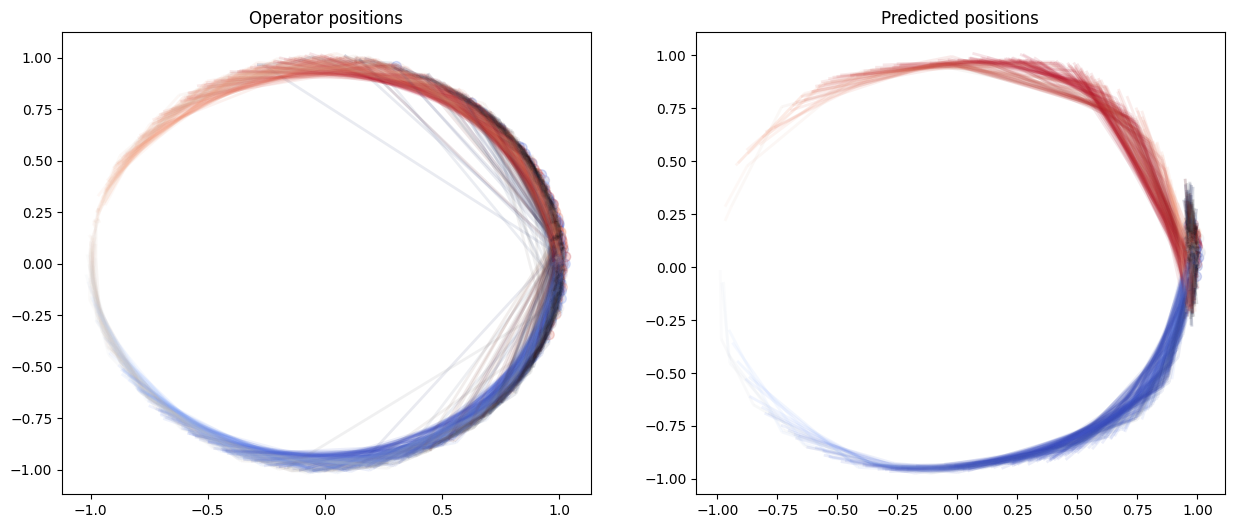

In [101]:
from matplotlib import cm
from matplotlib.collections import LineCollection

def generate_colors(colorbar_name, seq_len):
    colors = cm.get_cmap(colorbar_name)(np.linspace(0, 1, seq_len))
    return colors


def get_base_colors(initial_positions, colormap="coolwarm"):
    """
    Maps initial (x0, y0) positions to a base color using a colormap.
    """
    x0, y0 = initial_positions[:, 0], initial_positions[:, 1]  # Extract x0, y0
    # norm_x = (x0 - x0.min()) / (x0.max() - x0.min() + 1e-6)  # Normalize x0 to [0,1]
    norm_y = (y0 - y0.min()) / (y0.max() - y0.min() + 1e-6)  # Normalize y0 to [0,1]

    cmap = cm.get_cmap(colormap)  # Choose colormap
    # base_colors = cmap(0.5 * (norm_x + norm_y))  # Interpolate between x and y
    base_colors = cmap(norm_y)  

    return base_colors[:, :3]  # Use only RGB (ignore alpha)

def plot_trajectory(ax, trajectories, base_colors, title):
    """
    Plots trajectories with colors defined by initial conditions and a fading gradient.
    """
    batch_size, seq_len, _ = trajectories.shape
    for i in range(batch_size):  
        points = trajectories[i]  # Shape (seq_len, 2)
        segments = np.array([points[:-1], points[1:]]).transpose(1, 0, 2)  # Shape (seq_len-1, 2, 2)
        
        time_fade = np.linspace(1, 0, seq_len - 1)[:, None]  # Fade factor over time
        segment_colors = base_colors[i] * time_fade  # Multiply base color by fading factor

        lc = LineCollection(segments, colors=segment_colors, linewidth=2, alpha=0.1)
        ax.add_collection(lc)

    ax.autoscale()
    ax.set_title(title)

# Convert tensors to numpy

operatorpos = returned[-5] + torch.randn_like(returned[-5]) * 0.01
operatorpos = operatorpos[:, :, :2].cpu().detach()
predictedpos = returned[-2] + torch.randn_like(returned[-2]) * 0.01
predictedpos = predictedpos[:, :, :2].cpu().detach()

# Get base colors based on initial positions (x0, y0)
operator_base_colors = get_base_colors(operatorpos[:, -0])  # First timestep for operator
predicted_base_colors = get_base_colors(predictedpos[:, -0])  # First timestep for predictions

# Create figure
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Plot trajectories
plot_trajectory(ax[0], operatorpos, operator_base_colors, "Operator positions")
plot_trajectory(ax[1], predictedpos, predicted_base_colors, "Predicted positions")
# Scatter final positions
ax[0].scatter(operatorpos[:, -1, 0], operatorpos[:, -1, 1], color=operator_base_colors, s=50, label='Final Operator Position', alpha=0.2)
ax[1].scatter(predictedpos[:, -1, 0], predictedpos[:, -1, 1], color=predicted_base_colors,  s=50, label='Final Predicted Position', alpha = 0.2)

# # Add colorbars for time gradient
# sm = plt.cm.ScalarMappable(cmap="RdBu", norm=plt.Normalize(vmin=0, vmax=1))
# sm.set_array([])
# fig.colorbar(sm, ax=ax[0], label="Time Progression")

# sm = plt.cm.ScalarMappable(cmap="RdBu", norm=plt.Normalize(vmin=0, vmax=1))
# sm.set_array([])
# fig.colorbar(sm, ax=ax[1], label="Time Progression")
plt.show()

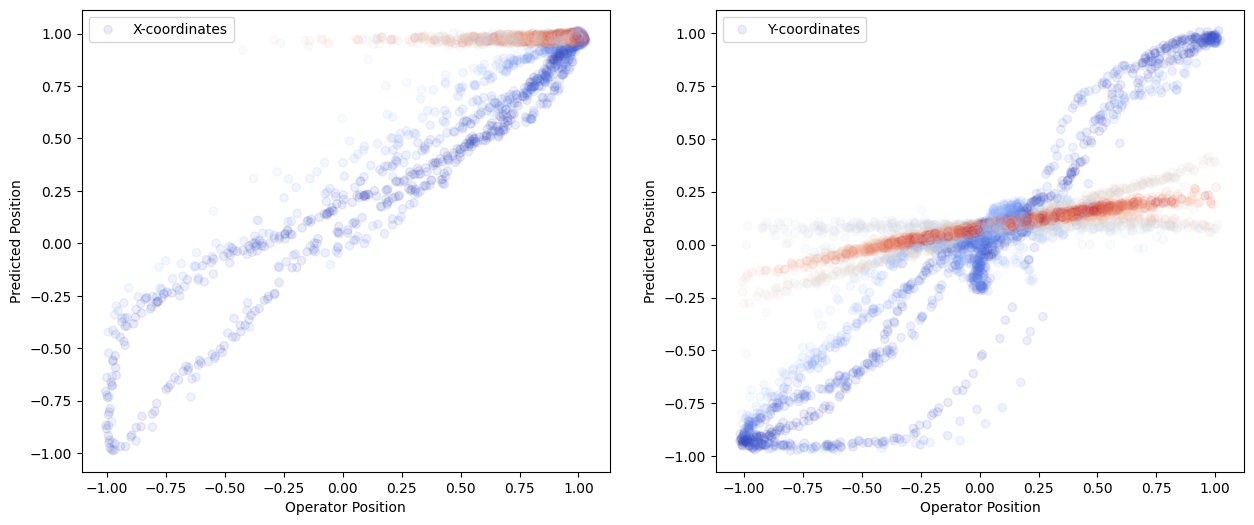

In [102]:
operator_x = operatorpos[:, 1:, 0].flatten()
operator_y = operatorpos[:, 1:, 1].flatten()
predicted_x = predictedpos[:, :, 0].flatten()
predicted_y = predictedpos[:, :, 1].flatten()

# Create a time-based color mapping
seq_len = operatorpos.shape[1] - 1
time_indices = np.linspace(0, 1, seq_len)  # Normalize time from 0 to 1

oneplot=False
if oneplot: 
    reds = cm.Reds(time_indices)  # Red colormap for x-coordinates
    blues = cm.Blues(time_indices)  # Blue colormap for y-coordinates

    # Repeat colors for all batches
    reds = np.tile(reds, (operatorpos.shape[0], 1))
    blues = np.tile(blues, (operatorpos.shape[0], 1))

    # Flatten colors
    reds = reds.reshape(-1, 4)  # Shape (batch*seq_len, 4)
    blues = blues.reshape(-1, 4)  # Shape (batch*seq_len, 4)
    # Create scatter plot
    fig, ax = plt.subplots(figsize=(8, 6))

    ax.scatter(operator_x, predicted_x, color=reds, alpha=0.1, label="X-coordinates (Red)")
    ax.scatter(operator_y, predicted_y, color=blues, alpha=0.1, label="Y-coordinates (Blue)")
    # Labels and legend
    ax.set_xlabel("Operator Position")
    ax.set_ylabel("Predicted Position")
    ax.set_title("Correlation between Operator and Predicted Positions")
    ax.legend()


else: 
    viridis = cm.coolwarm(time_indices)  # Viridis colormap for time progression
    viridis = np.tile(viridis, (operatorpos.shape[0], 1))
    viridis = viridis.reshape(-1, 4)
    # Create scatter plot
    fig, ax = plt.subplots(1, 2, figsize=(15, 6))

    ax[0].scatter(operator_x, predicted_x, color=viridis, alpha=0.1, label="X-coordinates")
    ax[1].scatter(operator_y, predicted_y, color=viridis, alpha=0.1, label="Y-coordinates")
    for a in ax: 
        a.set_xlabel("Operator Position")
        a.set_ylabel("Predicted Position")
        a.legend()


# Show plot
plt.show()


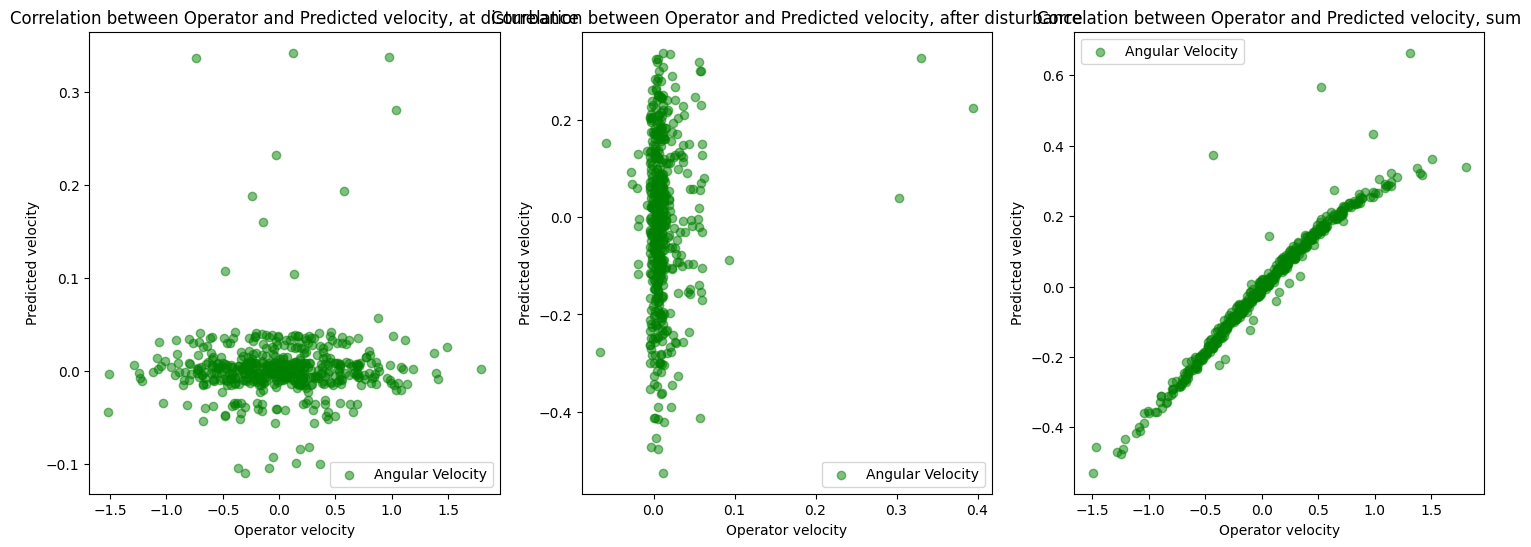

In [103]:
plot_disturbed = True
disturbance_index = 7
if inspect:
    out_index = -3
    predicted_index = -6
else: 
    out_index = -1
    predicted_index = -4

out_v = returned[out_index].cpu().detach()
predicted_v = returned[predicted_index].cpu().detach().numpy()
if not plot_disturbed:
    out_v_use = out_v.flatten()
    predicted_v_use = predicted_v.flatten()
    seq_len = predicted_v.shape[1] 
    time_indices = np.linspace(0, 1, seq_len)  # Normalize time from 0 to 1
    viridis = cm.Greens(time_indices)  # Red colormap for x-coordinates

    viridis = np.tile(viridis, (out_v.shape[0], 1))
    viridis = viridis.reshape(-1, 4)  # Shape (batch*seq_len, 4)
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(out_v_use, predicted_v_use, color=viridis, alpha=0.1, label="Angular Velocity")
    ax.set_xlabel("Operator velocity")
    ax.set_ylabel("Predicted velocity")
    ax.set_title("Correlation between Operator and Predicted velocity")
    ax.legend()
else: 
    out_v_use = ((out_v[:, disturbance_index]).flatten(), out_v[:, disturbance_index+1].flatten(), out_v[:, disturbance_index+1].flatten() + out_v[:, disturbance_index].flatten())
    predicted_v_use = ((predicted_v[:, disturbance_index]).flatten(), predicted_v[:, disturbance_index+1].flatten(), predicted_v[:, disturbance_index+1].flatten() + predicted_v[:, disturbance_index].flatten())
    fig, ax = plt.subplots(1, 3, figsize=(18, 6))
    for axi, out_v_u, predicted_v_u, title in zip(ax, out_v_use, predicted_v_use, ["at disturbance", "after disturbance", "sum"]):
        axi.scatter(out_v_u, predicted_v_u, color="green", alpha=0.5, label="Angular Velocity")
        axi.set_xlabel("Operator velocity")
        axi.set_ylabel("Predicted velocity")
        axi.set_title(f"Correlation between Operator and Predicted velocity, {title}")
        axi.legend()


# Show plot
plt.show()

In [234]:
out_v.shape

torch.Size([100, 8, 1])

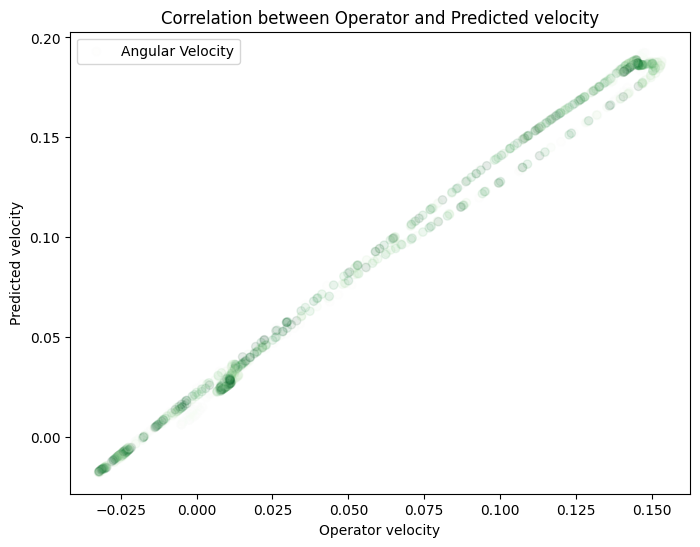

In [167]:
out_v = returned[-1].cpu().detach()
predicted_v = returned[-4].cpu().detach().numpy()
out_v_use = out_v.flatten()
predicted_v_use = predicted_v.flatten()
# Create a time-based color mapping
seq_len = predicted_v.shape[1] 
time_indices = np.linspace(0, 1, seq_len)  # Normalize time from 0 to 1
viridis = cm.Greens(time_indices)  # Red colormap for x-coordinates

# Repeat colors for all batches
viridis = np.tile(viridis, (out_v.shape[0], 1))

# Flatten colors
viridis = viridis.reshape(-1, 4)  # Shape (batch*seq_len, 4)

# Create scatter plot
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(out_v_use, predicted_v_use, color=viridis, alpha=0.1, label="Angular Velocity")

# Labels and legend
ax.set_xlabel("Operator velocity")
ax.set_ylabel("Predicted velocity")
ax.set_title("Correlation between Operator and Predicted velocity")
ax.legend()

# Show plot
plt.show()

In [55]:
q0 = torch.randn(100, 4).float().cuda()

q0 = q0/q0.norm(dim=-1, keepdim=True)
flip_mask = q0[:, 0] < 0
q0[flip_mask] = -q0[flip_mask]

init = mapnet(q0)

q = readoutnet(init[:, -128:])
q = q/torch.norm(q, dim=-1, keepdim=True)
flip_mask = q[:, 0] < 0
q[flip_mask] = -q[flip_mask]

fig = plt.figure(figsize=(10, 10))
ax0 = fig.add_subplot(121, projection='3d')
angles0 = torch.acos(q0[:, 0]) * 2
x0 = q0[:, 1:]/q0[:, 1:].norm(dim=-1, keepdim=True)
axis_angles0 = x0 * angles0.unsqueeze(1)
for i in range(100):
    ax0.scatter(*axis_angles0[i].cpu().detach().numpy())

ax = fig.add_subplot(122, projection='3d')
angles = torch.acos(q[:, 0]) * 2
x = q[:, 1:]/q[:, 1:].norm(dim=-1, keepdim=True)
axis_angles = x * angles.unsqueeze(1)
for i in range(100):
    ax.scatter(*axis_angles[i].cpu().detach().numpy())

init = mapnet(q0)
final_ = final[0, -1, -128:].expand(100, -1)

returned = trainer.model.forward_full(init, final_, 8)

RuntimeError: mat1 and mat2 shapes cannot be multiplied (100x24 and 6x128)

Text(0.5, 0, 'Time')

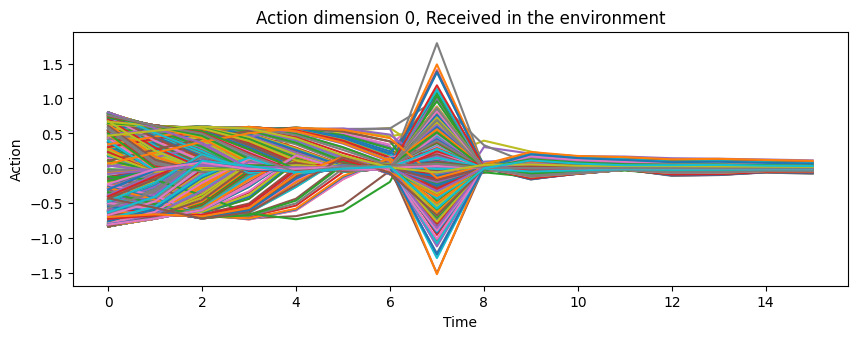

In [104]:
action_adjustment = 2 if inspect else 0
fig, axs = plt.subplots(dim, 1, figsize=(10, 3.3 * dim))
if dim == 1:
    axs = [axs]
plots = [axs[i].plot(returned[-1 - action_adjustment][:, :, i].cpu().detach().numpy().T) for i in range(dim)]

for i in range(dim): 
    axs[i].set_title(f"Action dimension {i}, Received in the environment")
    axs[i].set_ylabel("Action")

axs[-1].set_xlabel("Time")

Text(0.5, 0, 'Time')

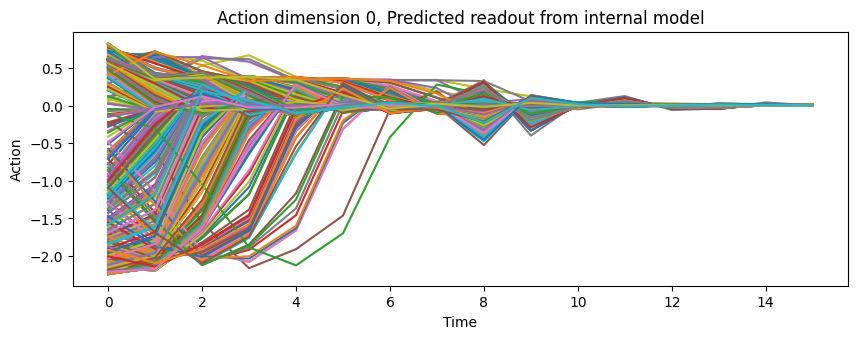

In [105]:
action_adjustment = 2 if inspect else 0
fig, axs = plt.subplots(dim, 1, figsize=(10, 3.3 * dim))
if dim == 1:
    axs = [axs]
plots = [axs[i].plot(returned[-4 - action_adjustment][:, :, i].cpu().detach().numpy().T) for i in range(dim)]

for i in range(dim): 
    axs[i].set_title(f"Action dimension {i}, Predicted readout from internal model")
    axs[i].set_ylabel("Action")

axs[-1].set_xlabel("Time")

Text(0.5, 0, 'Time')

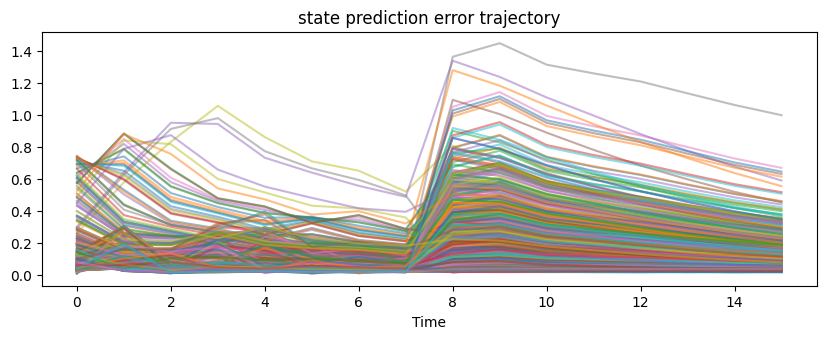

In [106]:
action_adjustment = 2 if inspect else 0
fig, axs = plt.subplots(1, 1, figsize=(10, 3.3 * 1))
- 1
plots = axs.plot(returned[-3 - action_adjustment][:, :].cpu().detach().numpy().T, alpha = 0.5)

axs.set_title(f"state prediction error trajectory")

axs.set_xlabel("Time")

In [315]:
# plt.imshow(trainer.model.im1.W_io.weight[:, rnn.rnn.rep_units:(rnn.rnn.rep_units + ring.state_size)].detach().cpu().numpy())
plt.imshow(trainer.model.im1.W_io.weight[:, :ring.state_size].detach().cpu().numpy())
# add color bar
plt.colorbar()
plt.title("IM1 weight matrix, state to action")

AttributeError: 'MLP' object has no attribute 'W_io'

RuntimeError: shape '[8, 16]' is invalid for input of size 32

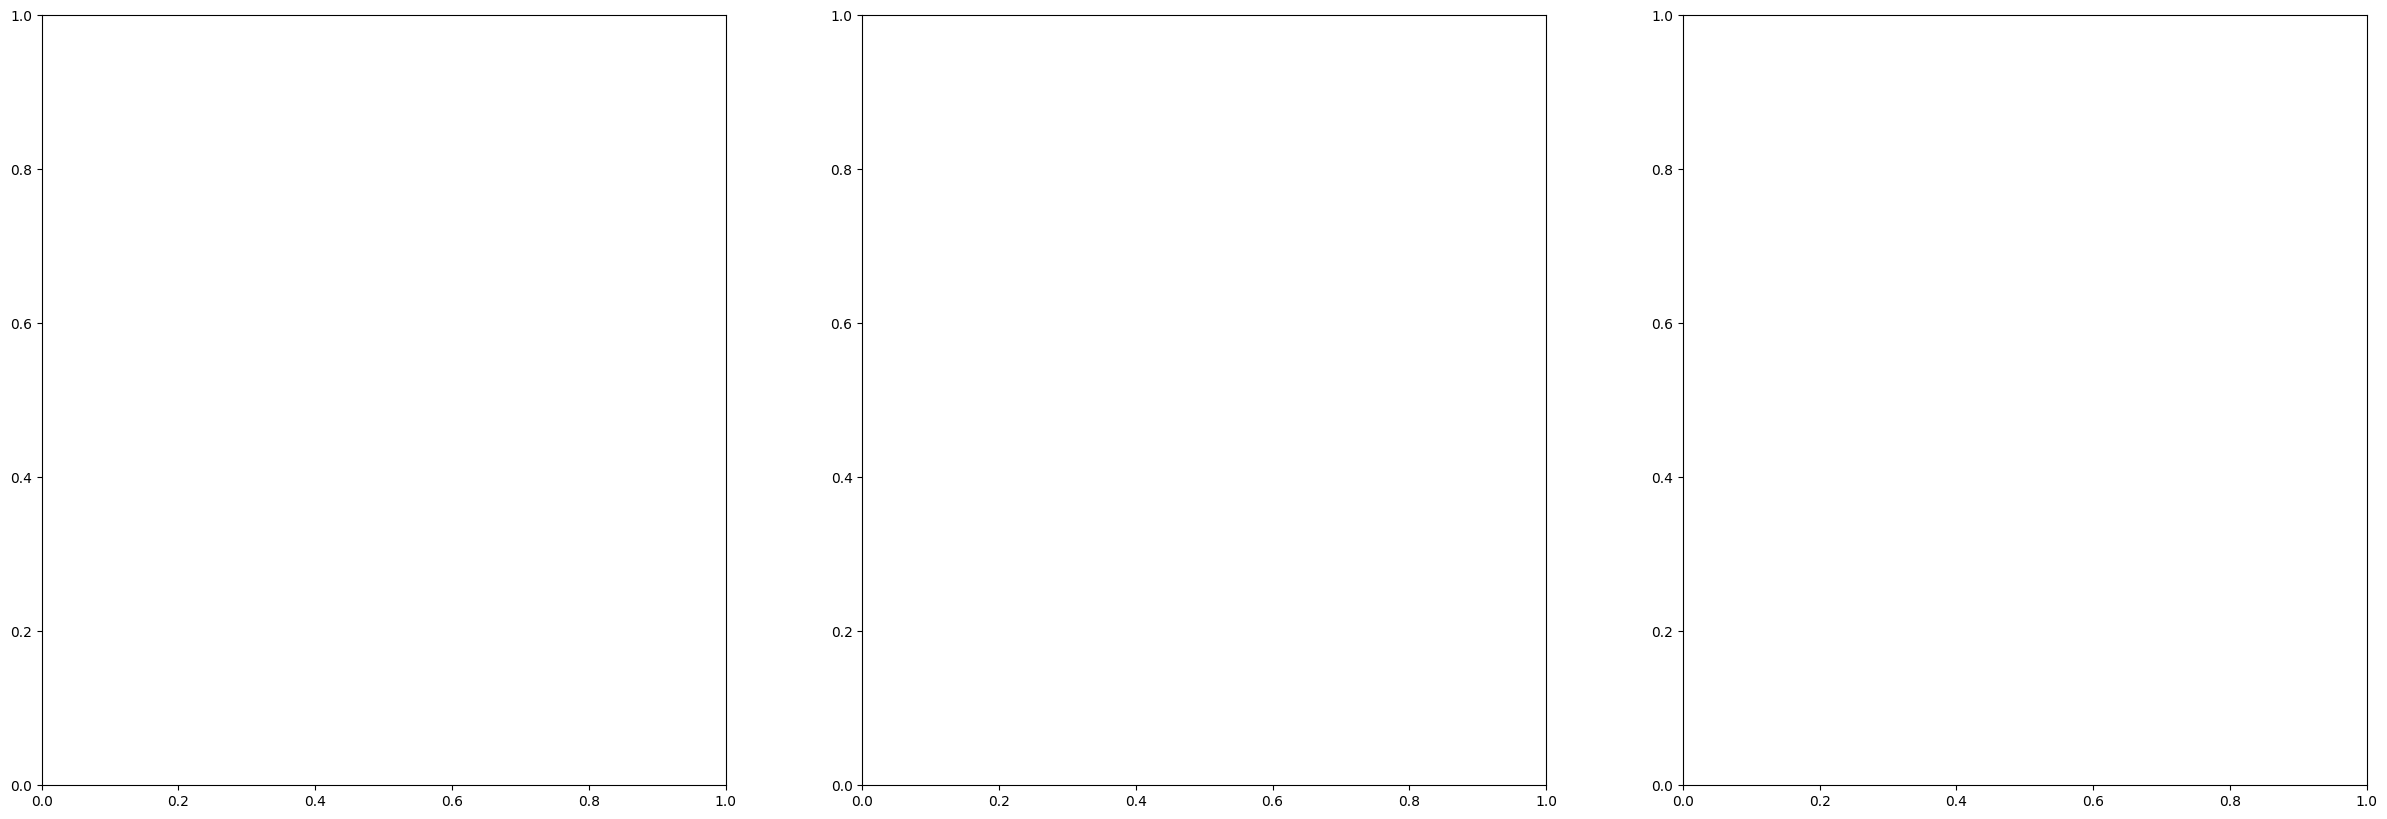

In [93]:
fig, ax = plt.subplots(1, 3, figsize=(30, 10))
ax[0].imshow(trainer.model.im1.W_io.weight[:, :rnn.rnn.rep_units].reshape(8, 16).detach().cpu().numpy())
ax[1].imshow(trainer.model.pred.W_io.weight[0, -rnn.rnn.rep_units:].reshape(8, 16).detach().cpu().numpy())
ax[2].imshow(trainer.model.pred.W_io.weight[1, -rnn.rnn.rep_units:].reshape(8, 16).detach().cpu().numpy())

# add color bar
ax[0].figure.colorbar(ax[0].images[0], ax=ax[0])
ax[1].figure.colorbar(ax[1].images[0], ax=ax[1])
ax[2].figure.colorbar(ax[2].images[0], ax=ax[2])

ax[0].set_title("IM1 weight matrix, rep to action")
ax[1].set_title("Predictor weight matrix, rep to state0")
ax[2].set_title("Predictor weight matrix, rep to state1")

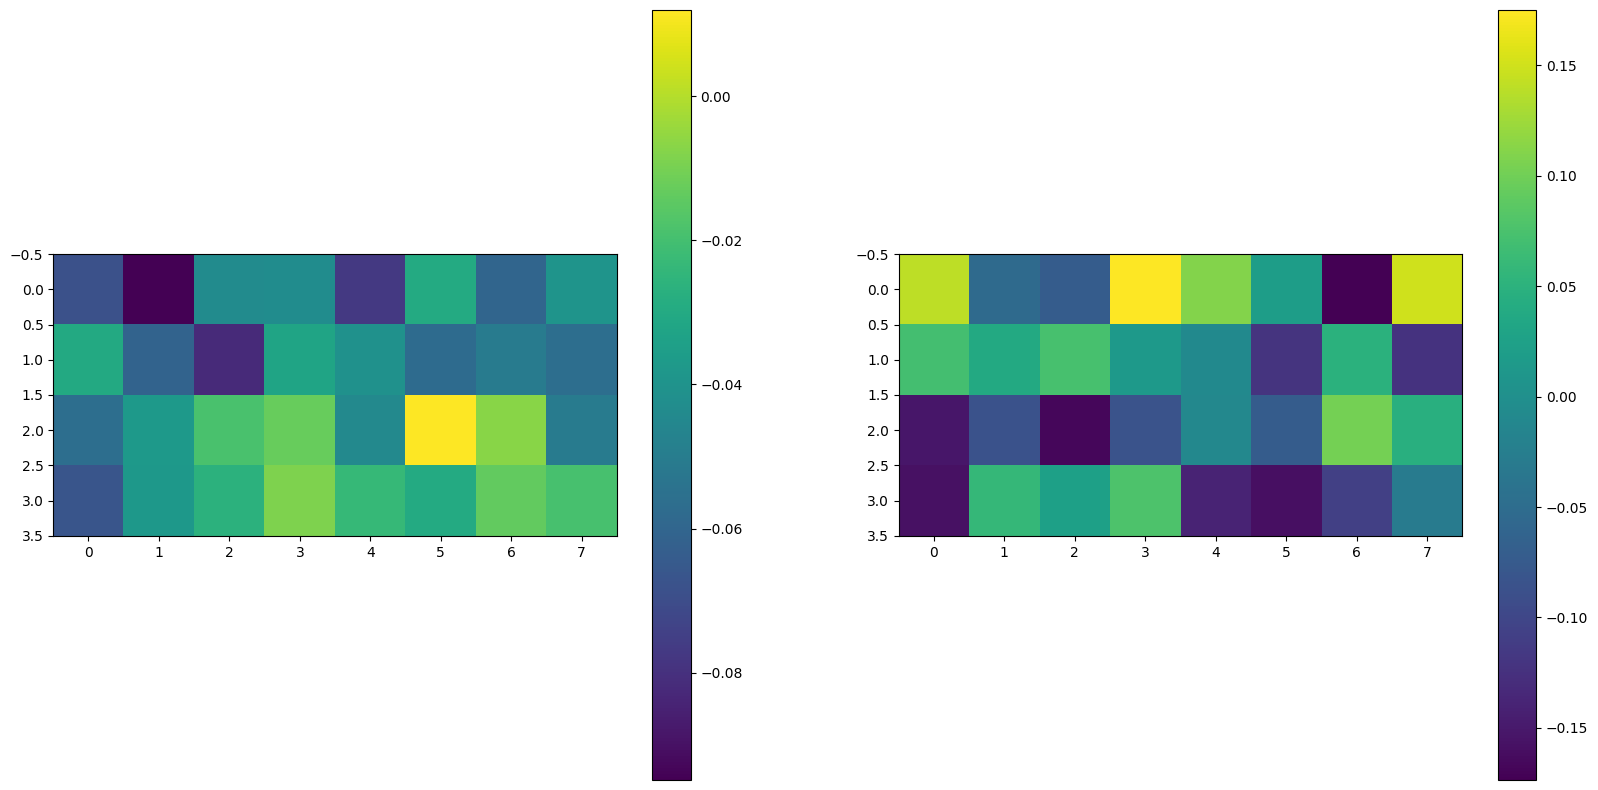

In [97]:
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
offset = use_rep * rnn.rnn.rep_units + use_feedback * ring.state_size

ax[0].imshow(trainer.model.im1.W_io.weight[:, offset:].reshape(4, 8).detach().cpu().numpy())

# ax[0].imshow(trainer.model.im1.W_io.weight[:, ring.state_size:].reshape(4, 8).detach().cpu().numpy())
ax[1].imshow(trainer.model.operator.readout_matrix.weight[:, :].reshape(4, 8).detach().cpu().numpy())


[ax[i].figure.colorbar(ax[i].images[0], ax = ax[i]) for i in range(2)]

Text(0.5, 1.0, 'IM1 vs Operator weight matrix')

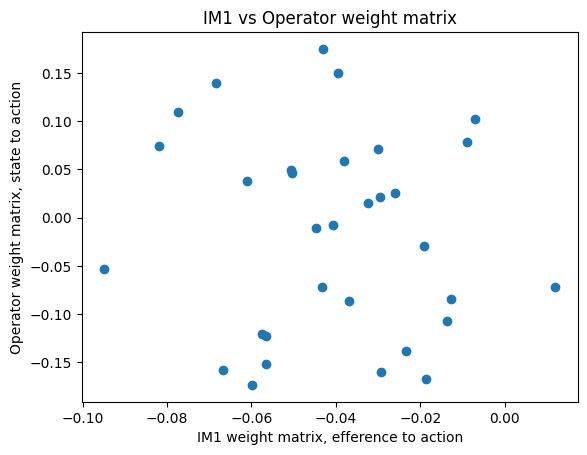

In [98]:
plt.scatter(trainer.model.im1.W_io.weight[:, offset:].reshape(-1).detach().cpu().numpy(), trainer.model.operator.readout_matrix.weight[:, :].reshape(-1).detach().cpu().numpy())
plt.xlabel("IM1 weight matrix, efference to action")
plt.ylabel("Operator weight matrix, state to action")
plt.title("IM1 vs Operator weight matrix")

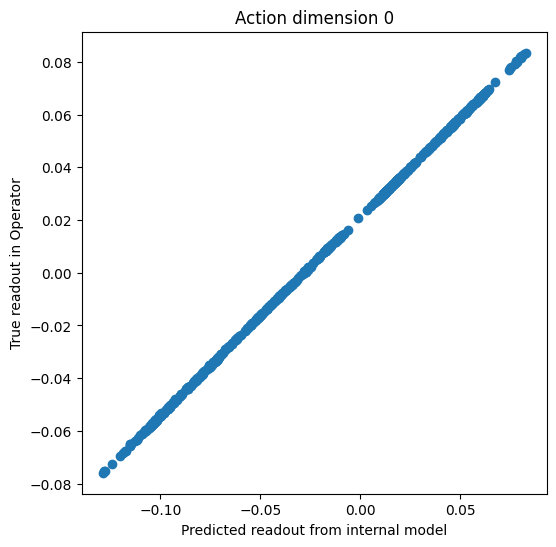

In [99]:
action_adjustment = 2 if inspect else 0
fig, axs = plt.subplots(1, dim, figsize=(6 * dim, 6))
if dim == 1:
    axs = [axs]
plots = [axs[i].scatter(returned[-4 - action_adjustment][:, :, i].reshape(-1).cpu().detach().numpy().T, returned[-1 - action_adjustment][:, :, i].reshape(-1).cpu().detach().numpy().T) for i in range(dim)]
for i in range(dim): 
    axs[i].set_title(f"Action dimension {i}")
    axs[i].set_xlabel("Predicted readout from internal model")
    axs[i].set_ylabel("True readout in Operator")

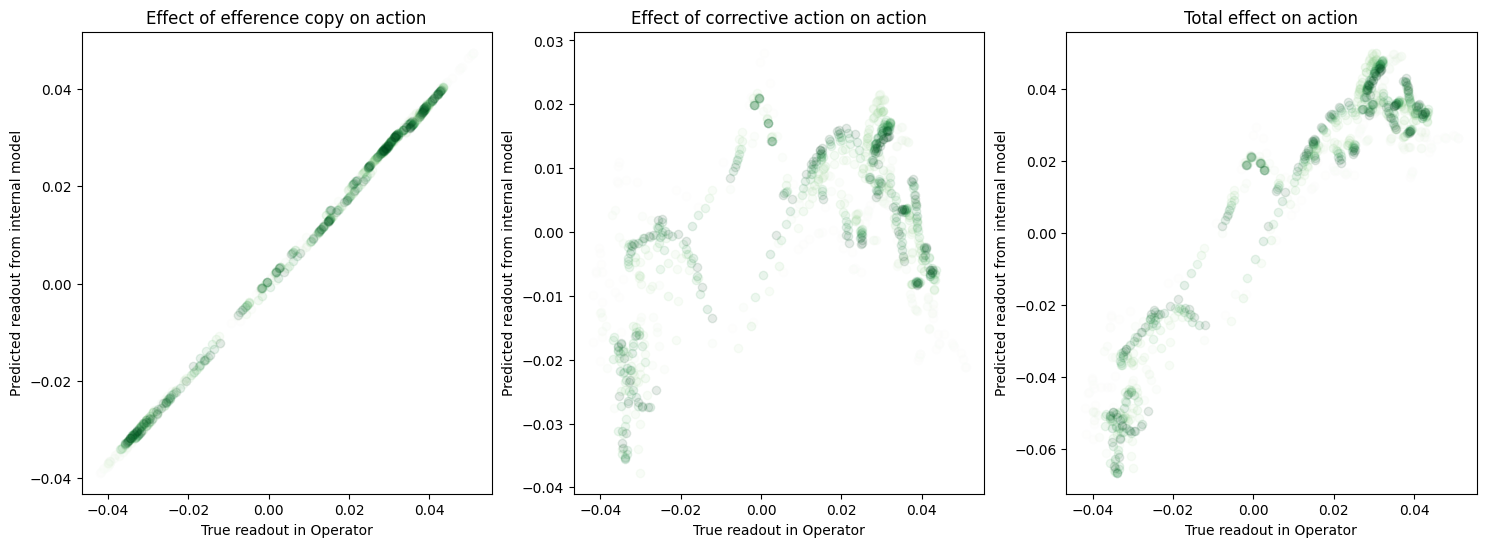

In [138]:
colors = cm.Greens(np.linspace(0, 1, returned[-3].shape[1]))
# now dissect what exactly the network is doing: i.e., we consider the contribution of the corrective action and the effect of the efference copy. 
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
for i, c in zip(range(returned[-3].shape[1]), colors):
    efference = returned[-1][:, i].reshape(-1).cpu().detach().numpy().T
    afference = returned[-2][:, i].reshape(-1).cpu().detach().numpy().T
    reference = returned[-3][:, i].reshape(-1).cpu().detach().numpy().T

    total = afference + efference

    alpha = 0.1  # Set the alpha value for transparency

    axs[0].scatter(reference, efference, color=c, alpha=alpha)
    axs[0].set_title("Effect of efference copy on action")
    axs[0].set_xlabel("True readout in Operator")
    axs[0].set_ylabel("Predicted readout from internal model")

    axs[1].scatter(reference, afference, color=c, alpha=alpha)
    axs[1].set_title("Effect of corrective action on action")
    axs[1].set_xlabel("True readout in Operator")
    axs[1].set_ylabel("Predicted readout from internal model")

    axs[2].scatter(reference, total, color=c, alpha=alpha)
    axs[2].set_title("Total effect on action")
    axs[2].set_xlabel("True readout in Operator")
    axs[2].set_ylabel("Predicted readout from internal model")